# Label Distribution

In [2]:
from pathlib import Path

# === Update these to match your dataset ===
INPUT_CSV = Path("/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv")
OUTPUT_DIR = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op")

# Your column names in the CSV
TITLE_COL   = "title"         # title column
BODY_COL = "body"            # body column
LABELS_COL = "Tags"       # comma-separated labels

# Canonical label set (use your exact labels)
CANON_LABELS = [
    "Abuse", "Aggression", "Sexual", "Medical", "Mental Health",
    "Discrimination", "Pregnancy","Not Applicable"
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Config set. Output dir:", OUTPUT_DIR.resolve())


✅ Config set. Output dir: /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op


In [3]:
import pandas as pd

df = pd.read_csv(INPUT_CSV)
print("Loaded dataframe shape:", df.shape)

# Sanity Check 
missing = [c for c in [TITLE_COL, BODY_COL, LABELS_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Create a unified text column for downstream analyses
def _safe_str(x):
    return "" if pd.isna(x) else str(x)

df["text"] = df.apply(lambda r: (_safe_str(r[TITLE_COL]).strip() + " " + _safe_str(r[BODY_COL]).strip()).strip(), axis=1)

# Quick peek
display(df[[TITLE_COL, BODY_COL, "text", LABELS_COL]].head(3))
print("Nulls per column:\n", df[[TITLE_COL, BODY_COL, "text", LABELS_COL]].isna().sum())


Loaded dataframe shape: (4994, 6)


,title,body,text,Tags
0,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Complications after abortion? Hi everyone, Ive...","Medical, Pregnancy, Mental Health"
1,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,Second MA abortion today and I'm absolutely te...,"Medical, Pregnancy, Mental Health"
2,Help needed/ live in Texas where abortion in b...,Anyone know of a legit site to support women i...,Help needed/ live in Texas where abortion in b...,Medical


Nulls per column:
 title    0
body     0
text     0
Tags     6
dtype: int64


In [4]:
from collections import Counter

def parse_label_list(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    # Split by comma; trim spaces
    return [t.strip() for t in str(x).split(",") if t.strip()]

df["labels_list"] = df[LABELS_COL].apply(parse_label_list)

# warn if any labels fall outside the canonical set
oov_counts = Counter(l for lst in df["labels_list"] for l in lst if l not in CANON_LABELS)
if oov_counts:
    print("⚠️ Found labels not in CANON_LABELS:", dict(oov_counts))
else:
    print("✅ All labels conform to CANON_LABELS")

display(df[[LABELS_COL, "labels_list"]].head(5))

✅ All labels conform to CANON_LABELS


,Tags,labels_list
0,"Medical, Pregnancy, Mental Health","[Medical, Pregnancy, Mental Health]"
1,"Medical, Pregnancy, Mental Health","[Medical, Pregnancy, Mental Health]"
2,Medical,[Medical]
3,Medical,[Medical]
4,"Pregnancy, Mental Health","[Pregnancy, Mental Health]"


In [5]:
def to_multi_hot(label_list, all_labels):
    return {f"y__{lab}": int(lab in label_list) for lab in all_labels}

mh = df["labels_list"].apply(lambda lst: to_multi_hot(lst, CANON_LABELS)).apply(pd.Series)

# ensure columns exist even if some labels never appear
for lab in CANON_LABELS:
    col = f"y__{lab}"
    if col not in mh.columns:
        mh[col] = 0

df = pd.concat([df, mh], axis=1)
df["has_any_label"] = df["labels_list"].apply(lambda lst: len(lst) > 0)

print("✅ Multi-hot columns added:", [c for c in df.columns if c.startswith("y__")][:5], "...")
display(df[[TITLE_COL, "text", "labels_list"] + [c for c in df.columns if c.startswith("y__")]].head(3))

✅ Multi-hot columns added: ['y__Abuse', 'y__Aggression', 'y__Sexual', 'y__Medical', 'y__Mental Health'] ...


,title,text,labels_list,y__Abuse,y__Aggression,y__Sexual,y__Medical,y__Mental Health,y__Discrimination,y__Pregnancy,y__Not Applicable
0,Complications after abortion?,"Complications after abortion? Hi everyone, Ive...","[Medical, Pregnancy, Mental Health]",0,0,0,1,1,0,1,0
1,Second MA abortion today and I'm absolutely te...,Second MA abortion today and I'm absolutely te...,"[Medical, Pregnancy, Mental Health]",0,0,0,1,1,0,1,0
2,Help needed/ live in Texas where abortion in b...,Help needed/ live in Texas where abortion in b...,[Medical],0,0,0,1,0,0,0,0


In [6]:
from itertools import combinations
from collections import Counter

# 5a) Label frequency
label_freq = (
    df[[c for c in df.columns if c.startswith("y__")]].sum(axis=0)
      .rename("count")
      .to_frame()
      .assign(label=lambda t: t.index.str.replace("^y__", "", regex=True))
      .loc[:, ["label", "count"]]
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# 5b) Pairwise co-occurrence (edge list)
pairs = Counter()
for lst in df["labels_list"]:
    if len(lst) >= 2:
        for a, b in combinations(sorted(lst), 2):
            pairs[(a, b)] += 1

coocc_df = (
    pd.DataFrame([{"label_a": a, "label_b": b, "count": c} for (a, b), c in pairs.items()])
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# 5c) Co-occurrence matrix (symmetric; diag = frequency)
coocc_matrix = pd.DataFrame(0, index=CANON_LABELS, columns=CANON_LABELS, dtype=int)
for (a, b), c in pairs.items():
    coocc_matrix.loc[a, b] = c
    coocc_matrix.loc[b, a] = c

for lab in CANON_LABELS:
    cnt = int(label_freq.loc[label_freq["label"] == lab, "count"].values[0]) if (label_freq["label"] == lab).any() else 0
    coocc_matrix.loc[lab, lab] = cnt

print("✅ Stats computed.")
display(label_freq.head(10))
display(coocc_df.head(10))
display(coocc_matrix.head())

✅ Stats computed.


,label,count
0,Mental Health,3550
1,Pregnancy,2652
2,Medical,1815
3,Abuse,1703
4,Sexual,918
5,Not Applicable,862
6,Discrimination,526
7,Aggression,196


,label_a,label_b,count
0,Mental Health,Pregnancy,2192
1,Medical,Pregnancy,1737
2,Abuse,Mental Health,1593
3,Medical,Mental Health,1466
4,Mental Health,Sexual,857
5,Abuse,Sexual,794
6,Discrimination,Mental Health,480
7,Discrimination,Pregnancy,319
8,Abuse,Discrimination,290
9,Abuse,Pregnancy,285


,Abuse,Aggression,Sexual,Medical,Mental Health,Discrimination,Pregnancy,Not Applicable
Abuse,1703,194,794,136,1593,290,285,0
Aggression,194,196,111,20,189,43,41,0
Sexual,794,111,918,129,857,114,183,0
Medical,136,20,129,1815,1466,179,1737,0
Mental Health,1593,189,857,1466,3550,480,2192,1


In [75]:
# === Cell 5B: All-size co-occurrence counts (k = 2..max) ===
# What & why:
# - Counts how often ANY subset of labels appears together in a post.
# - Example: counts for triples, quads, ... up to all labels present.
# - Outputs both a single table (all sizes) and separate CSVs per k.

from itertools import combinations
from collections import Counter
import pandas as pd

# Pull canonical labels and ensure we have labels_list
ALL_LABELS = CANON_LABELS

def itemset_counts_from_lists(label_lists, min_k=2, max_k=None):
    """
    Count frequency of all itemsets of size k in [min_k, max_k] across label_lists.
    Returns: dict k -> Counter({tuple(sorted(labels)): count})
    """
    max_len = max((len(lst) for lst in label_lists), default=0)
    if max_k is None:
        max_k = max_len
    k_to_counter = {k: Counter() for k in range(min_k, max_k + 1)}
    for lst in label_lists:
        unique = sorted(set(lst))  # avoid duplicates within a post
        for k in range(min_k, min(max_k, len(unique)) + 1):
            for comb in combinations(unique, k):
                k_to_counter[k][comb] += 1
    return k_to_counter

k_to_counts = itemset_counts_from_lists(df["labels_list"].tolist(), min_k=2)

# Flatten into a single DataFrame with columns: size_k, itemset (tuple), count
rows = []
for k, counter in k_to_counts.items():
    for itemset, c in counter.most_common():
        rows.append({"size_k": k, "itemset": itemset, "count": c})
coocc_all_sizes_df = pd.DataFrame(rows).sort_values(["size_k", "count"], ascending=[True, False]).reset_index(drop=True)

print("✅ Built all-size co-occurrence table.")
for k in sorted(coocc_all_sizes_df["size_k"].unique()):
    subset = coocc_all_sizes_df.query("size_k == @k")
    if not subset.empty:
        print(f"\n-- size_k = {k} (total {len(subset)} combinations) --")
        display(subset.head(3))

# Save: master + per-k CSVs
ALL_SIZES_PATH = OUTPUT_DIR / "label_cooccurrence_all_sizes.csv"
coocc_all_sizes_df.to_csv(ALL_SIZES_PATH, index=False)

# Also save separate files per k for convenience
for k, counter in k_to_counts.items():
    out = pd.DataFrame(
        [{"itemset": itemset, "count": c} for itemset, c in counter.most_common()]
    )
    out_path = OUTPUT_DIR / f"label_cooccurrence_k{k}.csv"
    out.to_csv(out_path, index=False)

print("✅ Saved:")
print(" -", ALL_SIZES_PATH.resolve())
for k in sorted(k_to_counts):
    print(" -", (OUTPUT_DIR / f"label_cooccurrence_k{k}.csv").resolve())

✅ Built all-size co-occurrence table.

-- size_k = 2 (total 23 combinations) --


,size_k,itemset,count
0,2,"(Mental Health, Pregnancy)",2192
1,2,"(Medical, Pregnancy)",1737
2,2,"(Abuse, Mental Health)",1593



-- size_k = 3 (total 36 combinations) --


,size_k,itemset,count
23,3,"(Medical, Mental Health, Pregnancy)",1404
24,3,"(Abuse, Mental Health, Sexual)",767
25,3,"(Discrimination, Mental Health, Pregnancy)",280



-- size_k = 4 (total 35 combinations) --


...


-- size_k = 6 (total 7 combinations) --


,size_k,itemset,count
115,6,"(Abuse, Discrimination, Medical, Mental Health...",8
116,6,"(Abuse, Aggression, Discrimination, Medical, M...",6
117,6,"(Abuse, Aggression, Medical, Mental Health, Pr...",5



-- size_k = 7 (total 1 combinations) --


,size_k,itemset,count
122,7,"(Abuse, Aggression, Discrimination, Medical, M...",3


✅ Saved:
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_all_sizes.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k2.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k3.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k4.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k5.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k6.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k7.csv


### Label Dist. Histogram

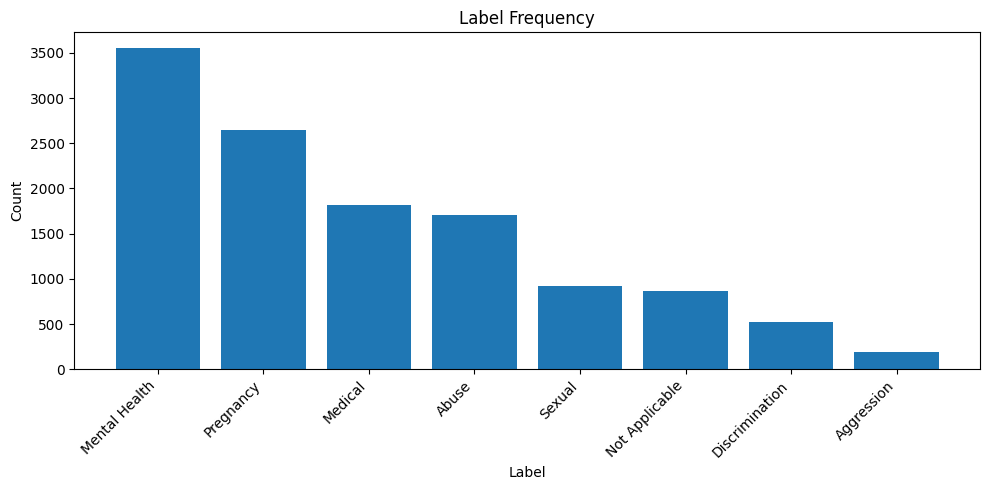

In [76]:
# === Cell 7: Bar chart for label frequencies ===
# What & why:
# - Visualizes how common each label is (sorted desc)
# - Helps you spot dominant or rare labels at a glance

import matplotlib.pyplot as plt

# If running in a fresh session (no memory), uncomment:
# import pandas as pd
# label_freq = pd.read_csv("./analysis_outputs/label_frequency.csv")

# Sort (should already be sorted, but just to be safe)
label_freq_plot = label_freq.sort_values("count", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(label_freq_plot["label"], label_freq_plot["count"])
plt.title("Label Frequency")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Co-Occurence

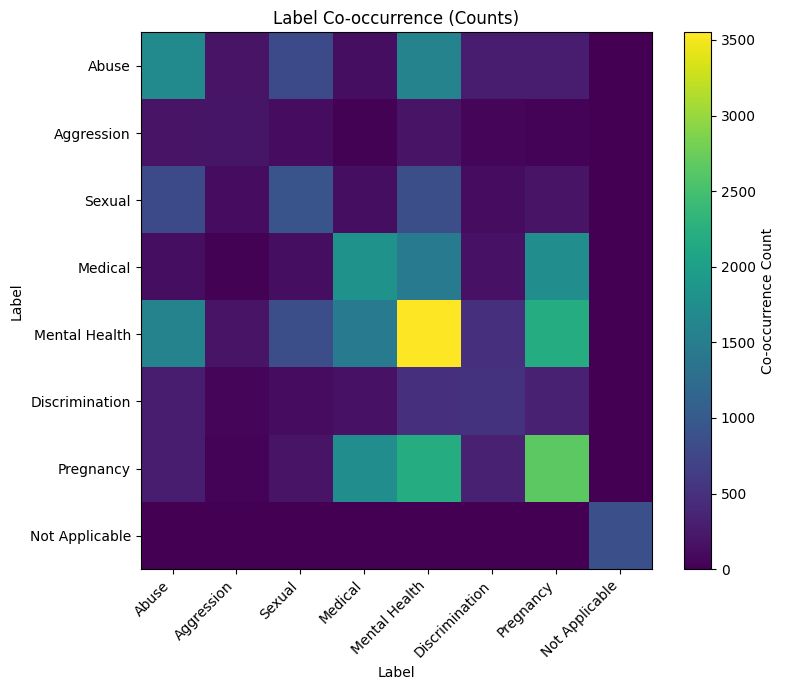

In [12]:
# === Cell 8: Co-occurrence heatmap ===
# What & why:
# - Shows which labels tend to appear together
# - Diagonal = individual label counts (handy as reference)
# - Off-diagonals = pair-wise co-occurrence counts

import numpy as np
import matplotlib.pyplot as plt

# If running in a fresh session (no memory), uncomment:
# import pandas as pd
# coocc_matrix = pd.read_csv("./analysis_outputs/label_cooccurrence_matrix.csv", index_col=0)

labels = list(coocc_matrix.index)
data = coocc_matrix.values.astype(float)

plt.figure(figsize=(8, 7))
im = plt.imshow(data, aspect="auto")  # default colormap
plt.title("Label Co-occurrence (Counts)")
plt.xlabel("Label")
plt.ylabel("Label")
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add a simple colorbar
cbar = plt.colorbar(im)
cbar.set_label("Co-occurrence Count")

plt.tight_layout()
plt.show()


### Correlation

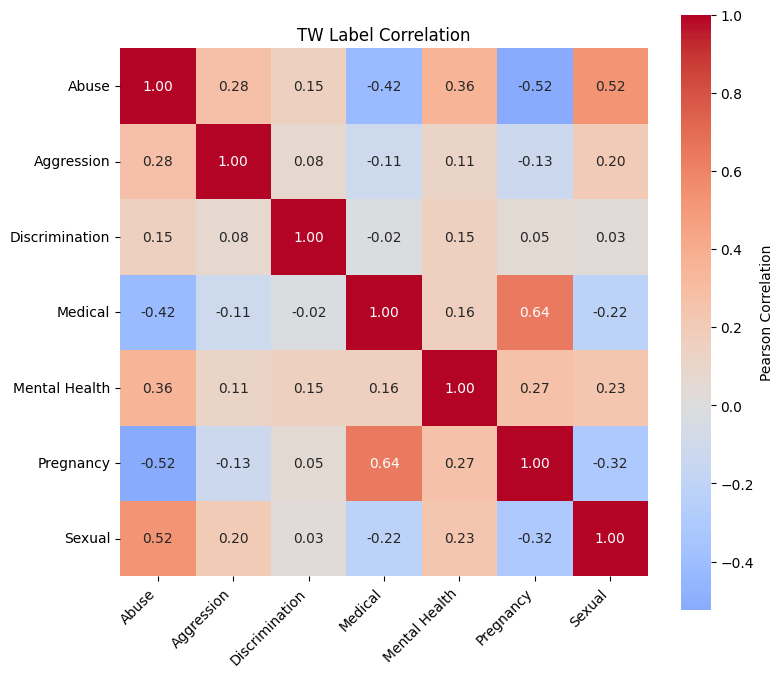

In [78]:
import seaborn as sns

df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# ---- exclude Not Applicable ----
EXCLUDE = {"not applicable", "na", "none", "nan"}

all_labels = sorted({
    lab for labs in df["labels_list"] for lab in labs
    if lab.strip().lower() not in EXCLUDE
})

# --- Create one-hot / multi-hot encoding ---
for lab in all_labels:
    df[f"label_{lab}"] = df["labels_list"].apply(lambda labs: int(lab in labs))

label_df = df[[f"label_{lab}" for lab in all_labels]]

# --- Compute Pearson correlation ---
corr = label_df.corr(method="pearson")

# --- Plot ---
plt.figure(figsize=(8, 7))
sns.heatmap(
    corr,
    xticklabels=all_labels,
    yticklabels=all_labels,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Pearson Correlation"},
    fmt=".2f"
)
plt.title("TW Label Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# --- SAVE HERE ---
plt.savefig("tw_label_correlation.pdf", format="pdf", bbox_inches="tight")

plt.show()

<Figure size 1000x600 with 0 Axes>

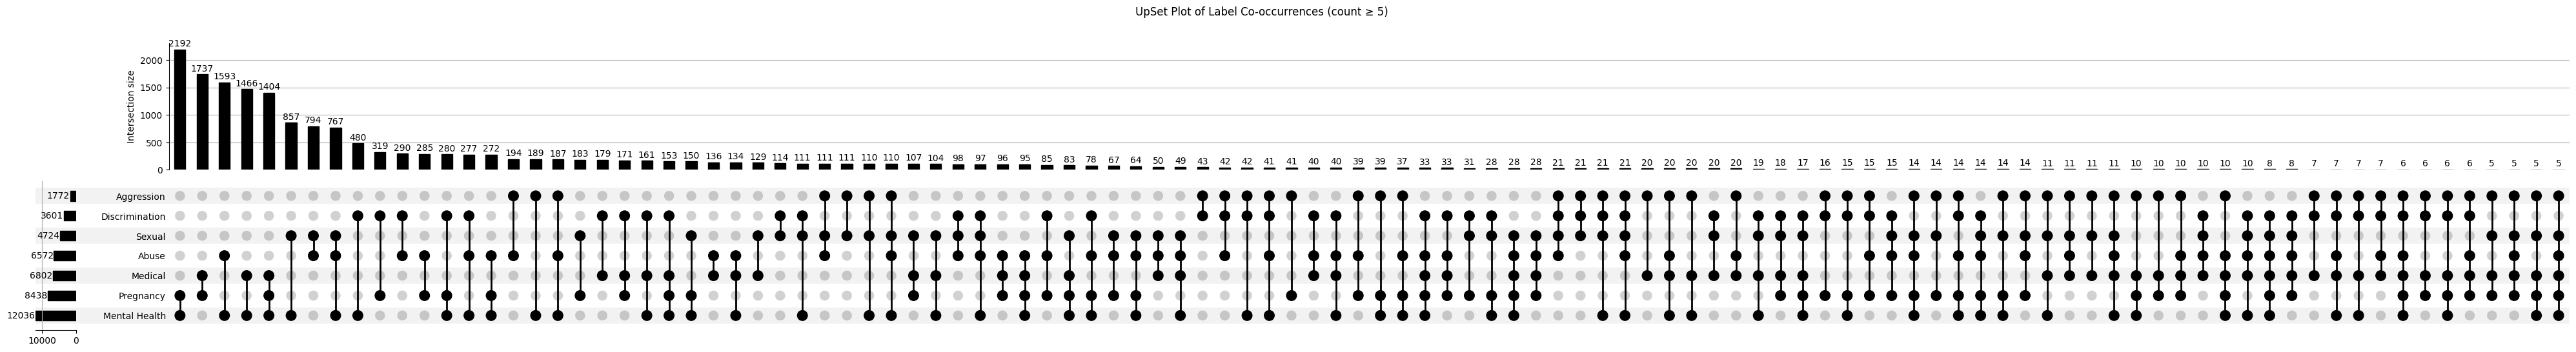

In [59]:
# === Cell 9: UpSet plot of frequent itemsets ===
# Shows intersections (any size) as bars; great for seeing which label combos are most common.

# !pip install upsetplot  # run once if needed

import pandas as pd
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# Choose a threshold so we don’t overwhelm the plot
MIN_COUNT_FOR_UPSET = 5  # tweak per your dataset size
subset = coocc_all_sizes_df[coocc_all_sizes_df["count"] >= MIN_COUNT_FOR_UPSET].copy()

if subset.empty:
    print("No itemsets meet the MIN_COUNT_FOR_UPSET threshold.")
else:
    # Convert tuples to list of strings for from_memberships
    memberships = subset["itemset"].apply(lambda t: list(t))
    data = from_memberships(memberships, data=subset["count"])

    plt.figure(figsize=(10, 6))
    UpSet(data, show_counts=True, sort_by='cardinality').plot()
    plt.suptitle("UpSet Plot of Label Co-occurrences (count ≥ {})".format(MIN_COUNT_FOR_UPSET))
    plt.show()

# Topic Modelling

In [7]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd
from pathlib import Path

In [9]:
import json, re
from collections import Counter
import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import nltk
from nltk.corpus import stopwords as nltk_stop
from tqdm import tqdm

In [10]:
TP_OUTPUT_DIR = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/topic_modeling_outputs")
TP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Paths set.")

✅ Paths set.


In [12]:
TEXT_COL = "text"

# Drop empty posts
df = df[df[TEXT_COL].notna() & (df[TEXT_COL].str.strip() != "")]
print("After dropping empty:", df.shape)

# Peek
display(df[[TEXT_COL, "labels_list"]].head(3))

After dropping empty: (4994, 17)


,text,labels_list
0,"Complications after abortion? Hi everyone, Ive...","[Medical, Pregnancy, Mental Health]"
1,Second MA abortion today and I'm absolutely te...,"[Medical, Pregnancy, Mental Health]"
2,Help needed/ live in Texas where abortion in b...,[Medical]


In [13]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [14]:
tqdm.pandas()

In [36]:
try:
    _ = nltk_stop.words("english")
except LookupError:
    import nltk; nltk.download("stopwords")

# 2) Base lists (general linguistic stopwords)
stop_spacy   = spacy.lang.en.stop_words.STOP_WORDS
stop_nltk    = set(nltk_stop.words("english"))
stop_sklearn = ENGLISH_STOP_WORDS
base_stop = set(stop_spacy) | stop_nltk | stop_sklearn

# 3) Domain/Reddit/informal fillers + contraction fragments
domain_stop = {
    # contractions & fragments (common after lemmatization)
    "im","ive","id","youre","theyre","weve","didn","doesn","wasn","werent","aint",
    "dont","didnt","doesnt","cant","couldnt","wouldnt","shouldnt","wont","arent",
    "ll","ve","re","d",
    # conversational fillers / light verbs / generic nouns
    "like","really","thing","things","stuff","lot","okay","ok","yeah","hmm","umm",
    "feel","felt","think","know","want","wanted","get","got","make","made","say","says","said",
    "people","person","one","someone","anyone","everyone","anything","something","everything","catherine",
    # web/reddit tokens
    "https","http","www","com","amp","reddit","r","u"
}

# 4) OPTIONAL: add top corpus-frequency noise (only if clearly non-content)
#    If you already have df["clean_text"], use that;
#    otherwise this will use df["text"] with minimal cleanup for a quick scan.
def quick_tokens(series):
    text = " ".join(series.astype(str).tolist()).lower()
    text = re.sub(r"http\S+|www\S+|@\w+|<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return [t for t in text.split() if len(t) > 2]

source_col = "clean_text" if "clean_text" in df.columns else "text"
most_common = Counter(quick_tokens(df[source_col])).most_common(40)

# Heuristic: add only obvious junky tops (edit this list after printing)
auto_add = {w for w, c in most_common if w in {
    "like","really","thing","things","stuff","people","got","said","say","know","think","want","make","made"
}}
domain_stop |= auto_add

# 5) Final hybrid list
custom_stopwords = base_stop | domain_stop
print(f"Hybrid stopwords size: {len(custom_stopwords)}")
print("Sample:", list(sorted(custom_stopwords))[:25])

# 6) Save to disk (so you can reuse)
STOP_PATH = "custom_stopwords.json"
with open(STOP_PATH, "w") as f:
    json.dump(sorted(list(custom_stopwords)), f, indent=2)
print(f"✅ Saved hybrid stopwords to {STOP_PATH}")

# 7) Helper to load later (if needed)
def load_custom_stopwords(path="custom_stopwords.json"):
    with open(path) as f:
        return set(json.load(f))

Hybrid stopwords size: 473
Sample: ["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'ain', 'aint', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am']
✅ Saved hybrid stopwords to custom_stopwords.json


In [37]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|@\w+|<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.pos_ in {"NOUN","VERB","ADJ","ADV"} and token.lemma_ not in custom_stopwords
        and len(token.lemma_) > 2
        and not token.is_punct
        and not token.like_num
    ]
    return " ".join(tokens)

In [38]:
df["clean_text"] = df["text"].progress_apply(clean_text)
print("✅ Cleaned and lemmatized text ready for topic modeling.")

100%|██████████| 4994/4994 [01:48<00:00, 46.02it/s]

✅ Cleaned and lemmatized text ready for topic modeling.


In [39]:
# === Required imports for custom UMAP + HDBSCAN models ===
import umap
import hdbscan
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

In [70]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")  
# 2️⃣ Dimensionality reduction (UMAP)
umap_model = umap.UMAP(
    n_neighbors=15,         # local vs. global structure (10–50)
    n_components=5,         # dimensionality of the embedding space (default=5)
    min_dist=0.0,           # how tightly UMAP packs points (0.0 = dense)
    metric='cosine',        # cosine is best for sentence embeddings
    random_state=42
)

# 3️⃣ Clustering model (HDBSCAN)
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,    # same as min_topic_size for consistency
    metric='euclidean',     # metric used after UMAP
    cluster_selection_method='eom', 
    prediction_data=True
)

# 4️⃣ Create BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,               # plug in custom UMAP
    hdbscan_model=hdbscan_model,         # plug in custom HDBSCAN
    min_topic_size=15,                   # small enough to catch niche themes
    n_gram_range=(1, 2),                 # include bigrams
    top_n_words=10,                      # number of words per topic to show
    calculate_probabilities=True,        # enables topic probability output
    verbose=True,
    language="english",
    nr_topics='auto'
)

In [37]:
# texts = df[TEXT_COL].tolist()
# topics, probs = topic_model.fit_transform(texts)

# # Save results to df
# df["topic_id"] = topics
# df["topic_probability"] = probs

# # Summary of discovered topics
# topic_info = topic_model.get_topic_info()
# display(topic_info.head(10))
# print(f"Total unique topics (excluding -1 outliers): {(topic_info.Topic != -1).sum()}")

In [27]:
# topic_info = topic_model.get_topic_info()
# display(topic_info.head(10))

In [71]:
import numpy as np, json

MODEL_DIR        = TP_OUTPUT_DIR / "bertopic_model"
DOC_TOPICS_PATH  = TP_OUTPUT_DIR / "document_topics.csv"
TOPIC_INFO_PATH  = TP_OUTPUT_DIR / "topic_summary.csv"
PROB_NPY_PATH    = TP_OUTPUT_DIR / "document_topic_probas.npy"

# 1) Fit model (heavy step)
texts = df["clean_text"].astype(str).tolist()
topics, probs = topic_model.fit_transform(texts)   # make sure topic_model was created with calculate_probabilities=True

# 2) Put assignments into df (avoid 2D assignment bug)
df["topic_id"] = topics

probs = np.asarray(probs)          # shape: (N_docs, N_topics)
df["topic_prob_max"] = probs.max(axis=1)  # 1-D, safe

# Top-K topic ids/probs (always create top1..top3; fill NaN if fewer topics exist)
K = min(3, probs.shape[1])
topk_idx = np.argsort(-probs, axis=1)[:, :K]             # indices of top-K topics
topk_val = np.take_along_axis(probs, topk_idx, axis=1)   # their probabilities

df["top1_topic_id"]   = topk_idx[:, 0] if K >= 1 else np.nan
df["top1_topic_prob"] = topk_val[:, 0] if K >= 1 else np.nan
df["top2_topic_id"]   = topk_idx[:, 1] if K >= 2 else np.nan
df["top2_topic_prob"] = topk_val[:, 1] if K >= 2 else np.nan
df["top3_topic_id"]   = topk_idx[:, 2] if K >= 3 else np.nan
df["top3_topic_prob"] = topk_val[:, 2] if K >= 3 else np.nan

# Optional: store full probability vector sparsely as JSON (keeps all info in one column)
def sparse_json(row):
    nz = np.nonzero(row)[0]
    return json.dumps({int(i): float(row[i]) for i in nz})
df["topic_probs_json"] = [sparse_json(row) for row in probs]

# 3) Topic summary table
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))
print(f"Total unique topics (excluding -1 outliers): {(topic_info.Topic != -1).sum()}")

# 4) SAVE model + outputs immediately (so accidental reruns don’t matter)
topic_model.save(MODEL_DIR)
topic_info.to_csv(TOPIC_INFO_PATH, index=False)

export_cols = ["text","labels_list","topic_id","topic_prob_max",
               "top1_topic_id","top1_topic_prob",
               "top2_topic_id","top2_topic_prob",
               "top3_topic_id","top3_topic_prob",
               "topic_probs_json"]
existing_cols = [c for c in export_cols if c in df.columns]
df[existing_cols].to_csv(DOC_TOPICS_PATH, index=False)

np.save(PROB_NPY_PATH, probs)

print("\n✅ Saved:")
print(" - Model:", MODEL_DIR.resolve())
print(" - Topic summary:", TOPIC_INFO_PATH.resolve())
print(" - Document topics:", DOC_TOPICS_PATH.resolve())
print(" - Full prob matrix (.npy):", PROB_NPY_PATH.resolve())

2025-10-28 04:44:23,456 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [92]:
BASE = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/topic_modeling_outputs")
df_doc = pd.read_csv(BASE/"document_topics.csv")
out_pct = (df_doc["topic_id"] == -1).mean()*100
print(f"Outliers (topic = -1): {out_pct:.1f}%   ({(df_doc['topic_id']==-1).sum()} of {len(df_doc)})")

Outliers (topic = -1): 0.0%   (0 of 2000)


In [98]:
from sklearn.feature_extraction.text import CountVectorizer

more_noise = {
    # timeline fillers
    "week","weeks","day","days","start","started","happen","happened","time","work",
    # scraping/moderation artifacts
    "remove","removed","story","post","thread","edit","deleted"
}

custom_stopwords |= set(more_noise)

texts = df["clean_text"].astype(str).tolist()

# ✅ Fix: convert set → list
vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),   # ✅ convert set to list
    ngram_range=(1, 2),
    min_df=0.003,                        # keep tokens that appear in ≥0.3% of docs
    max_df=0.80,                         # drop tokens in >80% of docs
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

# Re-extract topic words with the improved vectorizer
topic_model.update_topics(texts, vectorizer_model=vectorizer_model, n_gram_range=(1, 2))

topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,0,1968,0_baby_come_abortion_pregnant,"[baby, come, abortion, pregnant, pregnancy, mi...",[parent absolutely hate husband cautionary tal...
1,1,32,1_abuser metoo_advice realize_affect look_assa...,"[abuser metoo, advice realize, affect look, as...","[removed, removed, remove]"


In [99]:
def topic_name(tm, t, topn=4):
    if t == -1: return "Outliers"
    words = [w for w,_ in tm.get_topic(t)[:topn]]
    return " / ".join(words)

topic_info["topic_name"] = topic_info["Topic"].apply(lambda t: topic_name(topic_model, t, 4))
topic_info = topic_info.rename(columns={"Count":"doc_count"})
display(topic_info[["Topic","topic_name","doc_count"]].head(15))

,Topic,topic_name,doc_count
0,0,baby / come / abortion / pregnant,1968
1,1,abuser metoo / advice realize / affect look / ...,32


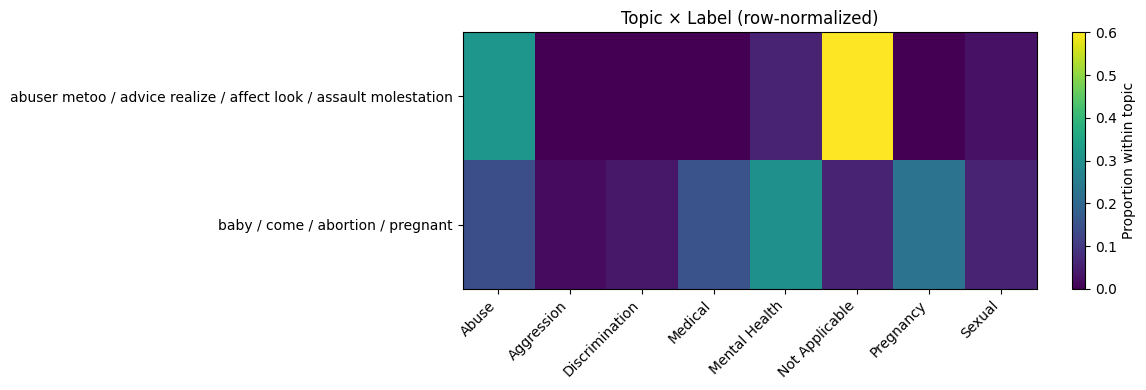

In [100]:
if isinstance(df_doc["labels_list"].iloc[0], str):
    df_doc["labels_list"] = df_doc["labels_list"].apply(eval)

# explode to one row per (doc, label)
exploded = df_doc.explode("labels_list")
exploded = exploded.rename(columns={"labels_list":"label"})

# counts per (topic, label)
ct = (exploded.groupby(["topic_id","label"]).size()
      .rename("count").reset_index())

# add topic names
name_map = dict(zip(topic_info["Topic"], topic_info["topic_name"]))
ct["topic_name"] = ct["topic_id"].map(name_map)

# make a pivot table for heatmap
pivot = ct.pivot_table(index="topic_name", columns="label", values="count", fill_value=0)
# normalize rows to proportions (optional; comment out if you want raw counts)
pivot_prop = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(12, max(4, 0.5*len(pivot_prop))))
im = plt.imshow(pivot_prop.values, aspect="auto")
plt.yticks(range(len(pivot_prop.index)), pivot_prop.index)
plt.xticks(range(len(pivot_prop.columns)), pivot_prop.columns, rotation=45, ha="right")
plt.colorbar(im, label="Proportion within topic")
plt.title("Topic × Label (row-normalized)")
plt.tight_layout()
plt.show()

In [109]:
try:
    topic_model.visualize_barchart(top_n_topics=10).show()
    topic_model.visualize_topics().show()
except Exception as e:
    print("(Interactive viz may require notebook extension) ->", e)

(Interactive viz may require notebook extension) -> zero-size array to reduction operation maximum which has no identity


In [105]:
from pathlib import Path

BASE = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/topic_modeling_outputs")
MODEL_DIR2 = BASE / "bertopic_model_clean"    # new folder so original stays intact
TOPIC_INFO_CLEAN = BASE / "topic_summary_clean.csv"
DOC_TOPICS_CLEAN = BASE / "document_topics_clean.csv"

# Update df_doc topic ids if you changed them (reduce_outliers/reduce_topics)
# If you ran Step 3 with new_topics, persist them:
if 'new_topics' in locals():
    df_doc["topic_id"] = new_topics

# Recompute top1 topic after merges (optional but recommended)
# (You can skip if you don't need these columns here.)
# Note: If you want exact new probabilities, you'd call transform() to get new probs.

MODEL_DIR2.parent.mkdir(parents=True, exist_ok=True)
topic_model.save(MODEL_DIR2)
topic_info.to_csv(TOPIC_INFO_CLEAN, index=False)
df_doc.to_csv(DOC_TOPICS_CLEAN, index=False)

print("✅ Saved updated assets:")
print(" -", MODEL_DIR2.resolve())
print(" -", TOPIC_INFO_CLEAN.resolve())
print(" -", DOC_TOPICS_CLEAN.resolve())

2025-10-17 18:38:46,011 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ Saved updated assets:
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/bertopic_model_clean
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/topic_summary_clean.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/document_topics_clean.csv


In [106]:
from collections import Counter
import numpy as np

def umass_coherence_for_topic(words, corpus_tokens, eps=1e-12):
    D = len(corpus_tokens)
    dfc = Counter()
    pc = Counter()
    for toks in corpus_tokens:
        uniq = set(toks)
        for w in uniq:
            dfc[w]+=1
        for i in range(1, len(words)):
            for j in range(i):
                if words[i] in uniq and words[j] in uniq:
                    pc[(words[i], words[j])] += 1
    score = 0.0; pairs=0
    for i in range(1, len(words)):
        for j in range(i):
            cw = pc[(words[i], words[j])]
            dw = dfc[words[j]]
            score += np.log((cw + eps) / (dw if dw>0 else 1))
            pairs += 1
    return score / max(pairs,1)

# lightweight tokenization
corpus_tokens = df["text"].str.lower().str.replace(r"[^a-z\s]", " ", regex=True).str.split()
coh = []
for t in topic_info.Topic[topic_info.Topic!=-1][:10]:
    words = [w for w,_ in topic_model.get_topic(t)[:10]]
    coh.append((t, umass_coherence_for_topic(words, corpus_tokens)))
print("UMass coherence (first 10 topics):")
for t, c in coh:
    print(f"Topic {t}: {c:.3f}")

UMass coherence (first 10 topics):
Topic 0: -1.441
Topic 1: -27.631


In [107]:
# explode labels and compute counts per (topic, label)
df_doc = pd.read_csv(BASE / "document_topics_clean.csv")
df_doc["labels_list"] = df_doc["labels_list"].apply(eval) if isinstance(df_doc["labels_list"].iloc[0], str) else df_doc["labels_list"]
df_ex = df_doc.explode("labels_list")

topic_label_counts = (df_ex.groupby(["topic_id","labels_list"])
                         .size().reset_index(name="count"))

# Normalize per-topic to proportions
topic_totals = topic_label_counts.groupby("topic_id")["count"].sum().rename("topic_total")
topic_label_props = topic_label_counts.merge(topic_totals, on="topic_id")
topic_label_props["prop"] = topic_label_props["count"] / topic_label_props["topic_total"]

topic_label_props.sort_values(["topic_id","prop"], ascending=[True,False]).head(20)

,topic_id,labels_list,count,topic_total,prop
4,0,Mental Health,1449,4798,0.302001
6,0,Pregnancy,1091,4798,0.227386
3,0,Medical,738,4798,0.153814
0,0,Abuse,686,4798,0.142976
7,0,Sexual,292,4798,0.060859
5,0,Not Applicable,275,4798,0.057316
2,0,Discrimination,186,4798,0.038766
1,0,Aggression,81,4798,0.016882
10,1,Not Applicable,21,35,0.600000
8,1,Abuse,11,35,0.314286


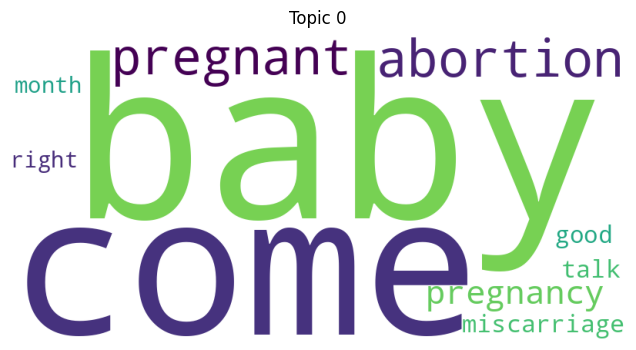

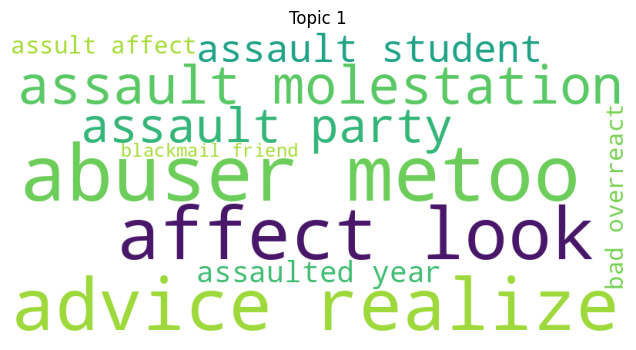

In [108]:
# !pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for t in topic_info.Topic[topic_info.Topic!=-1].head(6):
    words = topic_model.get_topic(t)  # list of (word, weight)
    freqs = {w: float(s) for w,s in words}
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freqs)
    plt.figure(figsize=(8,4)); plt.imshow(wc); plt.axis("off"); plt.title(f"Topic {t}")
    plt.show()

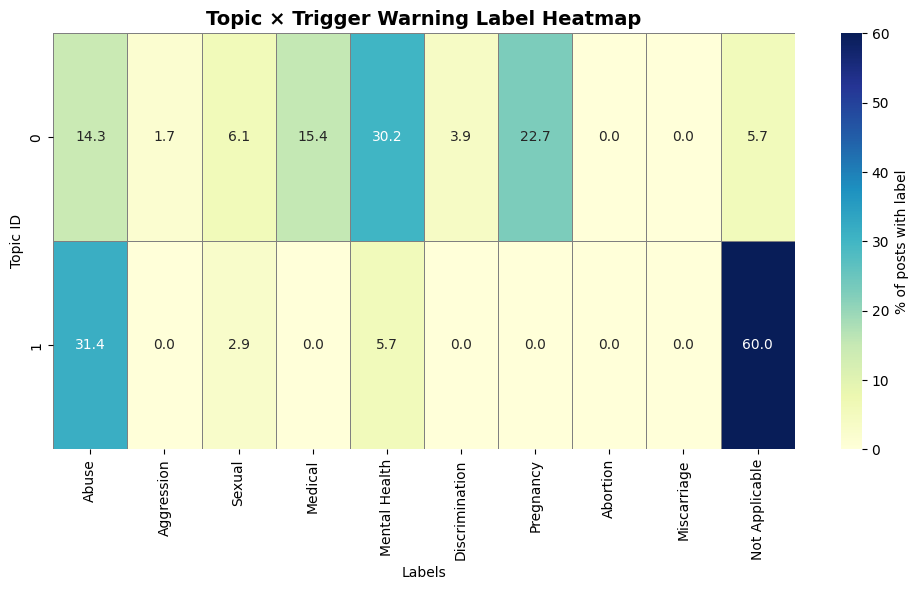

,Abuse,Aggression,Sexual,Medical,Mental Health,Discrimination,Pregnancy,Abortion,Miscarriage,Not Applicable
topic_id,,,,,,,,,,
0,14.3,1.7,6.1,15.4,30.2,3.9,22.7,0.0,0.0,5.7
1,31.4,0.0,2.9,0.0,5.7,0.0,0.0,0.0,0.0,60.0


In [111]:
# === TOPIC × LABEL HEATMAP ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1️⃣ Config
TOPIC_COL = "topic_id"
LABELS_COL = "Tags"   # change if your label column name differs
CANON_LABELS = [
    "Abuse", "Aggression", "Sexual", "Medical", "Mental Health",
    "Discrimination", "Pregnancy", "Abortion", "Miscarriage", "Not Applicable"
]

# 2️⃣ Prepare data
# Split multi-label strings into lists
df["labels_list"] = df[LABELS_COL].fillna("").apply(lambda x: [t.strip() for t in str(x).split(",") if t.strip()])

# Drop outliers (topic = -1)
df_no_outliers = df[df[TOPIC_COL] != -1].copy()

# 3️⃣ Count label occurrences per topic
topic_label_counts = []
for topic, group in df_no_outliers.groupby(TOPIC_COL):
    label_counts = Counter([lab for labs in group["labels_list"] for lab in labs])
    row = {lab: label_counts.get(lab, 0) for lab in CANON_LABELS}
    row["topic_id"] = topic
    topic_label_counts.append(row)

heat_df = pd.DataFrame(topic_label_counts).set_index("topic_id")

# 4️⃣ Normalize to percentages (optional, easier to interpret)
heat_df_pct = heat_df.div(heat_df.sum(axis=1), axis=0).fillna(0) * 100

# 5️⃣ Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heat_df_pct, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={'label': '% of posts with label'},
            linewidths=0.5, linecolor="gray")
plt.title("Topic × Trigger Warning Label Heatmap", fontsize=14, weight="bold")
plt.xlabel("Labels")
plt.ylabel("Topic ID")
plt.tight_layout()
plt.show()

# 6️⃣ Optional: display underlying table
display(heat_df_pct.round(1))


In [112]:
def summarize_topic(tm, t, topn=6):
    if t == -1: return "Mixed/outlier posts that did not fit a dense cluster."
    words = [w for w,_ in tm.get_topic(t)[:topn]]
    return f"Posts discussing {words[0]}, {words[1]}, and {words[2]} — often involving {words[3]}, {words[4]}, {words[5]}."

summ_df = topic_info[topic_info.Topic!=-1].copy()
summ_df["summary"] = summ_df["Topic"].apply(lambda t: summarize_topic(topic_model, t))
display(summ_df[["Topic","topic_name","doc_count","summary"]].head(20))

,Topic,topic_name,doc_count,summary
0,0,baby / come / abortion / pregnant,1968,"Posts discussing baby, come, and abortion — of..."
1,1,abuser metoo / advice realize / affect look / ...,32,"Posts discussing abuser metoo, advice realize,..."


In [114]:
from collections import Counter

LABELS_COL = "Tags"  # change if needed
df["labels_list"] = df[LABELS_COL].fillna("").apply(lambda x: [t.strip() for t in str(x).split(",") if t.strip()])

rows = []
for topic, g in df[df["topic_id"]!=-1].groupby("topic_id"):
    c = Counter(l for labs in g["labels_list"] for l in labs)
    total = len(g)
    top_labels = ", ".join([f"{lab} ({c[lab]/total:.0%})" for lab,_ in c.most_common(3)])
    rows.append({
        "Topic": topic,
        "topic_name": topic_name(topic_model, topic),
        "docs": total,
        "top_labels": top_labels
    })
topic_label_view = pd.DataFrame(rows).sort_values("docs", ascending=False)
display(topic_label_view.head(20))

,Topic,topic_name,docs,top_labels
0,0,baby / come / abortion / pregnant,1968,"Mental Health (74%), Pregnancy (55%), Medical ..."
1,1,abuser metoo / advice realize / affect look / ...,32,"Not Applicable (66%), Abuse (34%), Mental Heal..."


## Top 3 Labels Topic Modelling

### Mental Health

In [19]:
LABEL_TO_ANALYZE = "Mental Health"   # change to any other label if needed

# Make sure labels are in list form
df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# Filter rows that contain your target label
df_label = df[df["labels_list"].apply(lambda labs: LABEL_TO_ANALYZE in labs)].copy()

print(f"{LABEL_TO_ANALYZE}: {len(df_label)} posts selected")

Mental Health: 3550 posts selected


In [20]:
texts_label = df_label["clean_text"].astype(str).tolist()

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = umap.UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),  # your hybrid stopword list
    ngram_range=(1, 2),
    min_df=0.003,
    max_df=0.8,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

topic_model_label = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=10,
    n_gram_range=(1,2),
    language="english"
)

In [20]:
topics_label, probs_label = topic_model_label.fit_transform(texts_label)

topic_info_label = topic_model_label.get_topic_info()
display(topic_info_label.head(10))

for t in topic_info_label.Topic.tolist():
    if t == -1: continue
    print(f"Topic {t}: ", ", ".join(w for w, _ in topic_model_label.get_topic(t)[:10]))

2025-11-17 18:57:30,234 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/111 [00:00<?, ?it/s]

2025-11-17 19:05:07,680 - BERTopic - Embedding - Completed ✓
2025-11-17 19:05:07,681 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-17 19:05:41,669 - BERTopic - Dimensionality - Completed ✓
2025-11-17 19:05:41,670 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-17 19:05:41,885 - BERTopic - Cluster - Completed ✓
2025-11-17 19:05:41,889 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-17 19:05:43,336 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,2181,0_clot_cramping_sac_week day,"[clot, cramping, sac, week day, miss miscarria...",[experience prolong bleed doctor confirm anemb...
1,1,1369,1_sexual harassment_grope_sexually harass_cons...,"[sexual harassment, grope, sexually harass, co...",[wish sexual harassment sure bgette sexually h...


Topic 0:  clot, cramping, sac, week day, miss miscarriage, uterus, ectopic, embryo, misoprostol, chemical pregnancy
Topic 1:  sexual harassment, grope, sexually harass, consensual, porn, start touch, ask stop, nude, oral sex, consider sexual


In [25]:
def save_two_topics_vertical(tid1, tid2):
    freqs1 = {w: float(s) for w, s in topic_model_label.get_topic(tid1)}
    freqs2 = {w: float(s) for w, s in topic_model_label.get_topic(tid2)}

    wc1 = WordCloud(width=900, height=500, background_color="white",
                    stopwords=set(custom_stopwords)).generate_from_frequencies(freqs1)
    wc2 = WordCloud(width=900, height=500, background_color="white",
                    stopwords=set(custom_stopwords)).generate_from_frequencies(freqs2)

    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    axes[0].imshow(wc1)
    axes[0].set_title(f"Topic {tid1}")
    axes[0].axis("off")

    axes[1].imshow(wc2)
    axes[1].set_title(f"Topic {tid2}")
    axes[1].axis("off")

    plt.tight_layout()

    # 💾 SAVE HERE
    plt.savefig("mh_wc.pdf",
                format="pdf", bbox_inches="tight")

    plt.show()

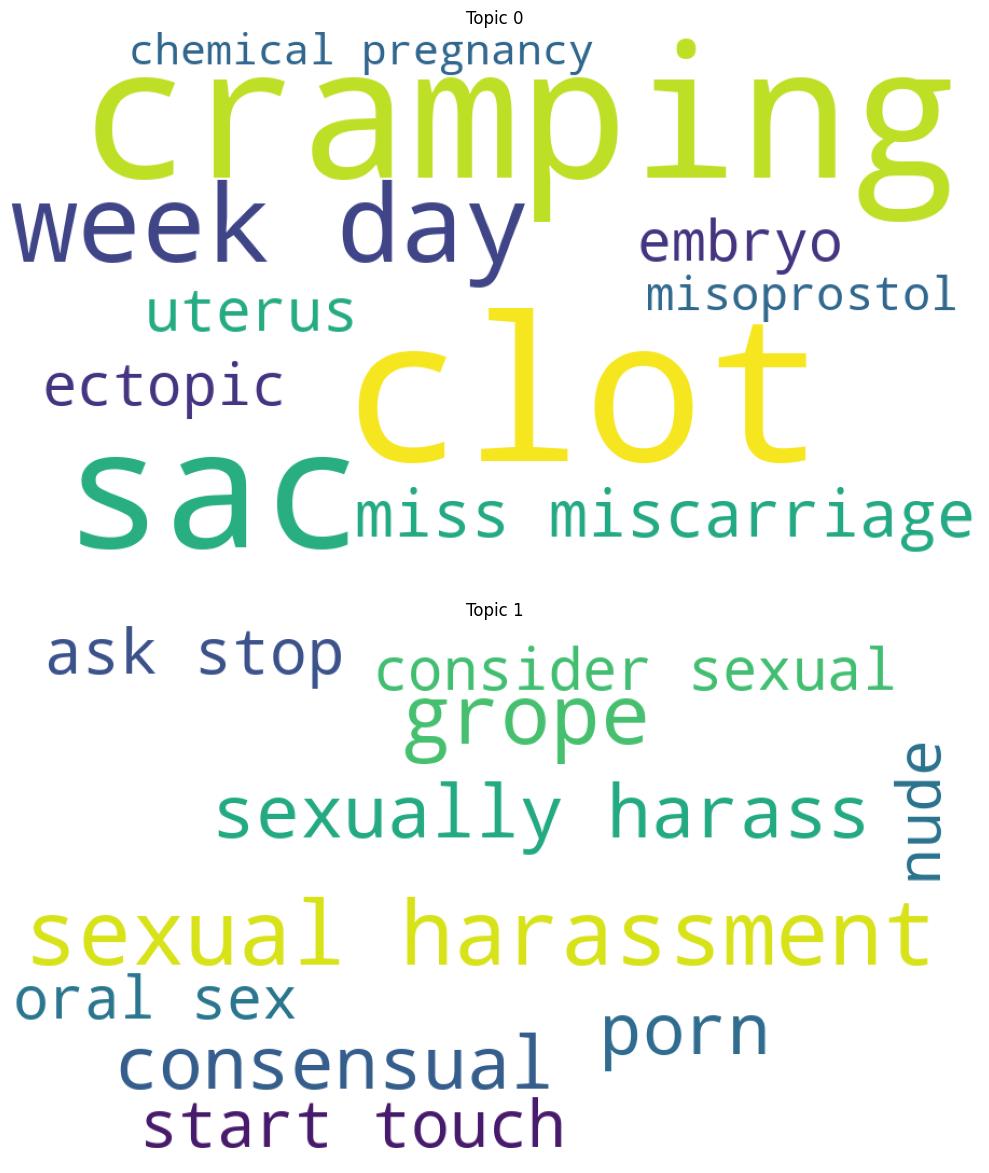

In [26]:
save_two_topics_vertical(0,1)

### Pregnancy

In [47]:
LABEL_TO_ANALYZE = "Pregnancy"   # change to any other label if needed

# Make sure labels are in list form
df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# Filter rows that contain your target label
df_label = df[df["labels_list"].apply(lambda labs: LABEL_TO_ANALYZE in labs)].copy()

print(f"{LABEL_TO_ANALYZE}: {len(df_label)} posts selected")

Pregnancy: 2652 posts selected


In [48]:
texts_label = df_label["clean_text"].astype(str).tolist()

In [49]:
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = umap.UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),  # your hybrid stopword list
    ngram_range=(1, 2),
    min_df=0.003,
    max_df=0.8,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

topic_model_label = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=10,
    n_gram_range=(1,2),
    language="english"
)

In [50]:
topics_label, probs_label = topic_model_label.fit_transform(texts_label)

topic_info_label = topic_model_label.get_topic_info()
display(topic_info_label.head(10))

for t in topic_info_label.Topic.tolist():
    if t == -1: continue
    print(f"Topic {t}: ", ", ".join(w for w, _ in topic_model_label.get_topic(t)[:10]))

2025-11-17 20:32:43,014 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/83 [00:00<?, ?it/s]

2025-11-17 20:37:23,299 - BERTopic - Embedding - Completed ✓
2025-11-17 20:37:23,302 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-17 20:37:37,859 - BERTopic - Dimensionality - Completed ✓
2025-11-17 20:37:37,861 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-17 20:37:38,017 - BERTopic - Cluster - Completed ✓
2025-11-17 20:37:38,022 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-17 20:37:39,011 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,18,-1_wish_hope_life_abortion,"[wish, hope, life, abortion, blighted, son, ba...",[blighted childfree recently experience miscar...
1,0,2606,0_abortion_help_life_work,"[abortion, help, life, work, month, good, bad,...",[today year anniversary abortion today mark ye...
2,1,16,1_ovum_blighted_blighted ovum_blight,"[ovum, blighted, blighted ovum, blight, tissue...",[possible blighted ovum ovulate track peak use...
3,2,12,2_molar_molar pregnancy_partial_partial molar,"[molar, molar pregnancy, partial, partial mola...",[probable partial molar pregnancy similar situ...


Topic 0:  abortion, help, life, work, month, good, bad, child, happen, friend
Topic 1:  ovum, blighted, blighted ovum, blight, tissue, ectopic, yolk, ivf, likely, measure
Topic 2:  molar, molar pregnancy, partial, partial molar, level, drop, weekly, complete molar, pathology, high


In [66]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

def save_three_topics_stacked_with_titles(tids,
                                          filename="three_topics_wc.pdf",
                                          gap=40,
                                          title_height=60):
    """
    tids: list of 3 topic IDs, e.g. [0,1,2]
    gap: vertical gap between word clouds (px)
    title_height: height of topic title area above each cloud
    """

    if len(tids) != 3:
        raise ValueError("Please pass exactly 3 topic IDs")

    stacked_parts = []

    for tid in tids:
        # ---- Generate word cloud ----
        freqs = {w: float(s) for w, s in topic_model_label.get_topic(tid)}
        wc = WordCloud(
            width=900, height=500, background_color="white",
            stopwords=set(custom_stopwords)
        ).generate_from_frequencies(freqs)
        wc_img = wc.to_array()

        h, w, _ = wc_img.shape

        # ---- Title bar ----
        title_bar = np.ones((title_height, w, 3), dtype=np.uint8) * 255

        # Add title using matplotlib later (easier & no cv2)
        stacked_parts.append((title_bar, f"Topic {tid}", w))  # save title info

        # ---- Add the WC image ----
        stacked_parts.append((wc_img, None, None))

        # ---- Gap ----
        gap_bar = np.ones((gap, w, 3), dtype=np.uint8) * 255
        stacked_parts.append((gap_bar, None, None))

    # Remove last gap
    stacked_parts = stacked_parts[:-1]

    # ---- Combine into one image ----
    images_only = [item[0] for item in stacked_parts]
    combined = np.vstack(images_only)

    # ---- Plot & overlay titles ----
    plt.figure(figsize=(combined.shape[1]/100, combined.shape[0]/100))
    plt.imshow(combined)
    plt.axis("off")

    # draw titles manually
    y_offset = 0
    for img, title, width in stacked_parts:
        if title is not None:
            # center text horizontally
            plt.text(width/2, y_offset + title_height*0.7,
                     title,
                     ha="center", va="center",
                     fontsize=12, color="black")
        y_offset += img.shape[0]

    plt.savefig(filename, format="pdf", bbox_inches="tight", pad_inches=0)
    plt.show()

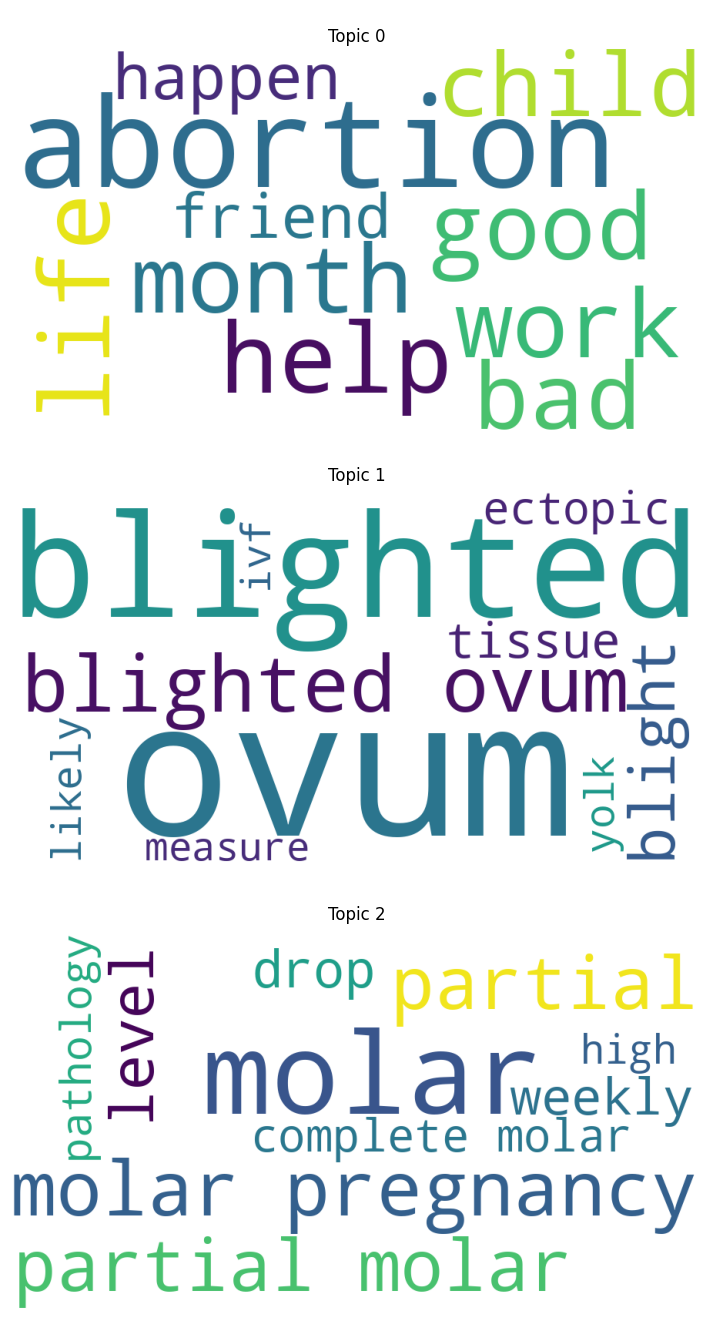

In [69]:
save_three_topics_stacked_with_titles([0, 1, 2],
                                      filename="preg_wc.pdf",
                                      gap=20,
                                      title_height=50)

### Abuse

In [40]:
LABEL_TO_ANALYZE = "Abuse"   # change to any other label if needed

# Make sure labels are in list form
df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# Filter rows that contain your target label
df_label = df[df["labels_list"].apply(lambda labs: LABEL_TO_ANALYZE in labs)].copy()

print(f"{LABEL_TO_ANALYZE}: {len(df_label)} posts selected")

Abuse: 1703 posts selected


In [41]:
texts_label = df_label["clean_text"].astype(str).tolist()

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = umap.UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),  # your hybrid stopword list
    ngram_range=(1, 2),
    min_df=0.003,
    max_df=0.8,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

topic_model_label = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=10,
    n_gram_range=(1,2),
    language="english"
)

In [43]:
topics_label, probs_label = topic_model_label.fit_transform(texts_label)

topic_info_label = topic_model_label.get_topic_info()
display(topic_info_label.head(10))

for t in topic_info_label.Topic.tolist():
    if t == -1: continue
    print(f"Topic {t}: ", ", ".join(w for w, _ in topic_model_label.get_topic(t)[:10]))

2025-11-18 00:24:01,068 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/54 [00:00<?, ?it/s]

2025-11-18 00:28:05,242 - BERTopic - Embedding - Completed ✓
2025-11-18 00:28:05,243 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-18 00:28:12,254 - BERTopic - Dimensionality - Completed ✓
2025-11-18 00:28:12,255 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-18 00:28:12,358 - BERTopic - Cluster - Completed ✓
2025-11-18 00:28:12,362 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-18 00:28:13,281 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,1678,0_tell_start_ask_talk,"[tell, start, ask, talk, come, day, remember, ...",[chest usually come conversation emotional mee...
1,1,25,1_assault remove_removed_abuser remove_remove ...,"[assault remove, removed, abuser remove, remov...","[sexual assault remove, friend sexually assaul..."


Topic 0:  tell, start, ask, talk, come, day, remember, sex, stop, need
Topic 1:  assault remove, removed, abuser remove, remove brother, remove rape, remove sexual, year remove, blackmail friend, assult remove, assaulted time


In [44]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def save_two_topics_vertical(tid1, tid2):
    freqs1 = {w: float(s) for w, s in topic_model_label.get_topic(tid1)}
    freqs2 = {w: float(s) for w, s in topic_model_label.get_topic(tid2)}

    wc1 = WordCloud(width=900, height=500, background_color="white",
                    stopwords=set(custom_stopwords)).generate_from_frequencies(freqs1)
    wc2 = WordCloud(width=900, height=500, background_color="white",
                    stopwords=set(custom_stopwords)).generate_from_frequencies(freqs2)

    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    axes[0].imshow(wc1)
    axes[0].set_title(f"Topic {tid1}")
    axes[0].axis("off")

    axes[1].imshow(wc2)
    axes[1].set_title(f"Topic {tid2}")
    axes[1].axis("off")

    plt.tight_layout()

    # 💾 SAVE HERE
    plt.savefig("abuse_wc.pdf",
                format="pdf", bbox_inches="tight")

    plt.show()

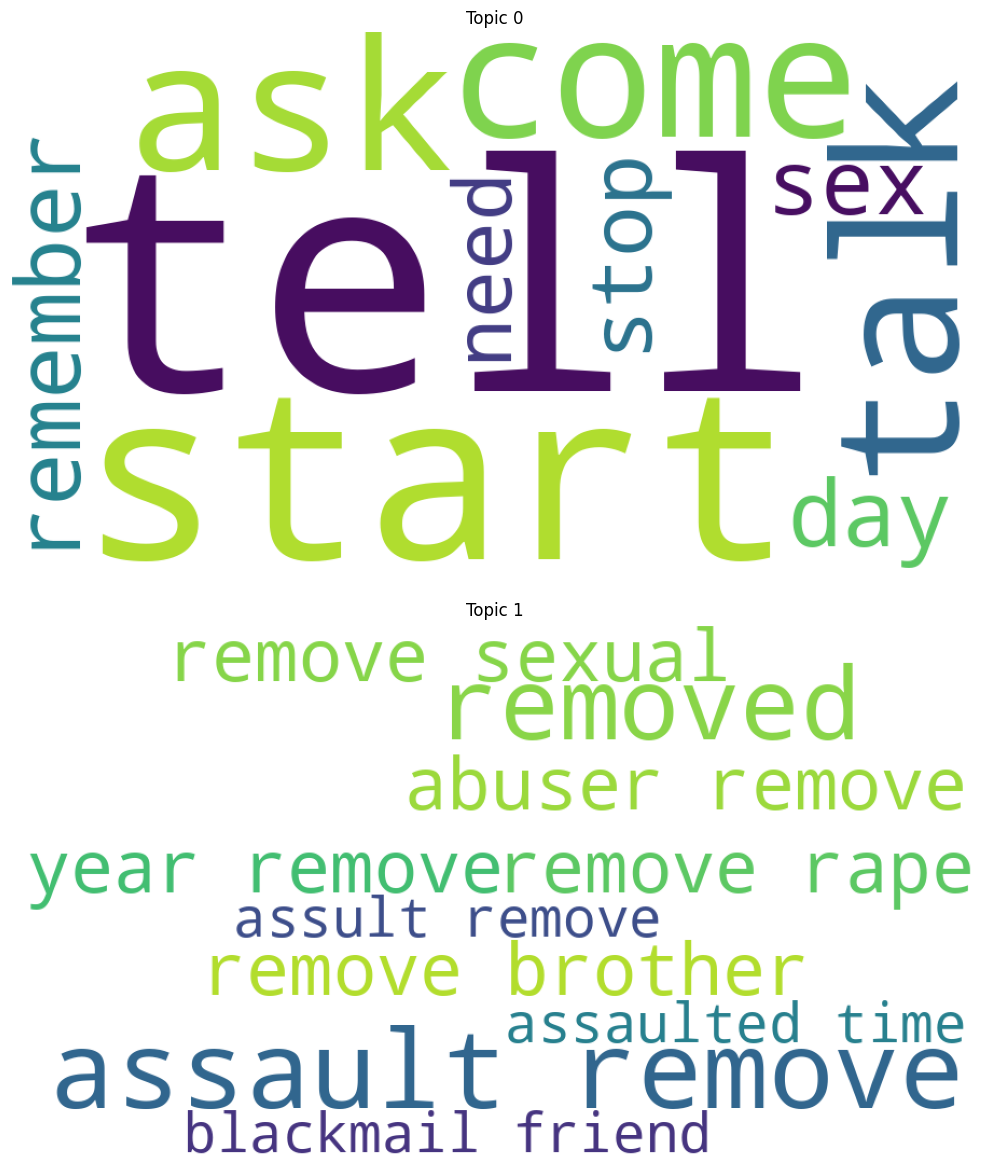

In [45]:
save_two_topics_vertical(0,1)

# LIWC

In [10]:
# # === Repair duplicates, rebuild prefixed Empath features, plot heatmap ===
# from empath import Empath
# import pandas as pd, numpy as np
# import seaborn as sns, matplotlib.pyplot as plt

# lexicon = Empath()

# LABELS_COL = "tags"  # <- adjust if different
# TEXT_COL_USED = "clean_text" if "clean_text" in df.columns else "text"

# # 0) Identify any prior (unprefixed) Empath category columns to drop
# #    We generate a temp empath result to know the raw category names.
# _tmp = pd.DataFrame([lexicon.analyze("test", normalize=True)])
# raw_empath_cols = [c.strip().lower().replace(" ", "_") for c in _tmp.columns]

# # 1) Normalize all current df column names once for matching
# norm_map = {c: (c.strip().lower().replace(" ", "_") if isinstance(c, str) else c) for c in df.columns}
# inv_map = {}
# for k, v in norm_map.items():
#     # keep first occurrence for inverse map
#     inv_map.setdefault(v, k)

# # 2) Build the set of columns to drop:
# to_drop = set()
# # a) any previous unprefixed empath cols (e.g., 'body','anger',...) if present
# to_drop |= {inv_map[c] for c in raw_empath_cols if c in inv_map}
# # b) any stale prefixed empath cols from earlier runs
# to_drop |= {c for c in df.columns if isinstance(c, str) and c.startswith("em_")}
# # c) never drop these core columns:
# protect = {LABELS_COL, TEXT_COL_USED, "labels_list", "topic_id"}
# to_drop -= protect

# if to_drop:
#     print(f"Dropping {len(to_drop)} stale Empath/duplicate columns:", sorted(map(str, to_drop))[:20], "...")
#     df = df.drop(columns=list(to_drop), errors="ignore")

# # 3) Recompute Empath per document
# doc_scores = df[TEXT_COL_USED].fillna("").astype(str).apply(lambda t: lexicon.analyze(t, normalize=True))
# empath_df = pd.DataFrame(doc_scores.tolist())
# empath_df.columns = [f"em_{c.strip().lower().replace(' ', '_')}" for c in empath_df.columns]

# # 4) Merge and enforce unique columns
# df = df.reset_index(drop=True)
# df = pd.concat([df, empath_df.reset_index(drop=True)], axis=1)
# # ensure unique column names (keep first)
# df = df.loc[:, ~df.columns.duplicated()]

# # 5) Ensure labels_list exists
# if "labels_list" not in df.columns:
#     df["labels_list"] = df[LABELS_COL].fillna("").apply(
#         lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
#     )

# # 6) Choose Empath categories to visualize (prefixed)
# desired = [
#     "sadness", "anger", "violence", "health", 
#     "sexual", "body", "fear", "joy", "disgust", "family"
# ]

# avail = [f"em_{c}" for c in desired if f"em_{c}" in df.columns]

# # Fallback: pick top-varying em_* if none of desired exist
# if not avail:
#     em_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("em_") and pd.api.types.is_numeric_dtype(df[c])]
#     var_rank = df[em_cols].var().sort_values(ascending=False)
#     avail = var_rank.head(20).index.tolist()

# missing = sorted(set(f"em_{c}" for c in desired) - set(avail))
# if missing:
#     print("ℹ️ Skipped missing categories:", [m.replace("em_","") for m in missing])

# # 7) Aggregate by label and plot heatmap
# expl = df.explode("labels_list")
# heat = expl.groupby("labels_list")[avail].mean().sort_index()

# plt.figure(figsize=(min(18, 2 + 0.6*len(avail)), 0.6*max(6, len(heat))))
# sns.heatmap(
#     heat,
#     cmap="coolwarm",
#     annot=True, fmt=".2f",
#     cbar_kws={"label": "Avg proportion"}
# )
# plt.title("Empath (LIWC-like) Category Strengths per Label")
# plt.xlabel("Category"); plt.ylabel("Label")
# plt.xticks(ticks=range(len(avail)), labels=[c.replace("em_", "") for c in avail], rotation=45, ha="right")
# plt.tight_layout(); plt.show()

In [1]:
import pandas as pd
from pathlib import Path

LIWC_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/LIWC-22 Results - 5000_Posts_Annotations - Combi___ - LIWC Analysis.csv"

df = pd.read_csv(LIWC_PATH)
print(df.shape)
df.head(3)

(4994, 125)


,id,subreddit,title,body,Tags,Unnamed: 5,Segment,WC,Analytic,Clout,...,nonflu,filler,AllPunc,Period,Comma,QMark,Exclam,Apostro,OtherP,Emoji
0,1ljxynj,abortion,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Medical, Pregnancy, Mental Health",NaN,1,124,2.40,1.00,...,0.0,0.0,22.58,4.84,5.65,1.61,0.0,7.26,3.23,0.0
1,1ljxtt8,abortion,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,"Medical, Pregnancy, Mental Health",NaN,1,204,17.43,14.37,...,0.0,0.0,13.24,4.41,0.98,1.47,0.0,5.39,0.98,0.0
2,1ljwhkb,abortion,Help needed/ live in Texas where abortion in b...,Anyone know of a legit site to support women i...,Medical,NaN,1,37,85.33,56.18,...,0.0,0.0,10.81,0.00,0.00,5.41,0.0,2.70,2.70,0.0


In [2]:
for i in df.columns :
    print(i, end=",")

id,subreddit,title,body,Tags,Unnamed: 5,Segment,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic,function,pronoun,ppron,i,we,you,shehe,they,ipron,det,article,number,prep,auxverb,adverb,conj,negate,verb,adj,quantity,Drives,affiliation,achieve,power,Cognition,allnone,cogproc,insight,cause,discrep,tentat,certitude,differ,memory,Affect,tone_pos,tone_neg,emotion,emo_pos,emo_neg,emo_anx,emo_anger,emo_sad,swear,Social,socbehav,prosocial,polite,conflict,moral,comm,socrefs,family,friend,female,male,Culture,politic,ethnicity,tech,Lifestyle,leisure,home,work,money,relig,Physical,health,illness,wellness,mental,substances,sexual,food,death,need,want,acquire,lack,fulfill,fatigue,reward,risk,curiosity,allure,Perception,attention,motion,space,visual,auditory,feeling,time,focuspast,focuspresent,focusfuture,Conversation,netspeak,assent,nonflu,filler,AllPunc,Period,Comma,QMark,Exclam,Apostro,OtherP,Emoji,

In [3]:
# 1️⃣ Unify label column
LABELS_COL = "Tags"   # edit if different
df[LABELS_COL] = df[LABELS_COL].fillna("").astype(str)

# 2️⃣ Build list-type labels (multi-label safe)
df["labels_list"] = df[LABELS_COL].apply(lambda s: [t.strip() for t in s.split(",") if t.strip()])

# 3️⃣ Pick key LIWC categories to visualize (short-paper subset)
desired_liwc = [
    "emo_pos","emo_neg","emo_anx","","emo_anger","emo_sad",
    "health","body","sexual","family","social","death"
]

# Keep only those that exist
use_cols = [c for c in desired_liwc if c in df.columns]
print("Using LIWC columns:", use_cols)

Using LIWC columns: ['emo_pos', 'emo_neg', 'emo_anx', 'emo_anger', 'emo_sad', 'health', 'body', 'sexual', 'family', 'death']


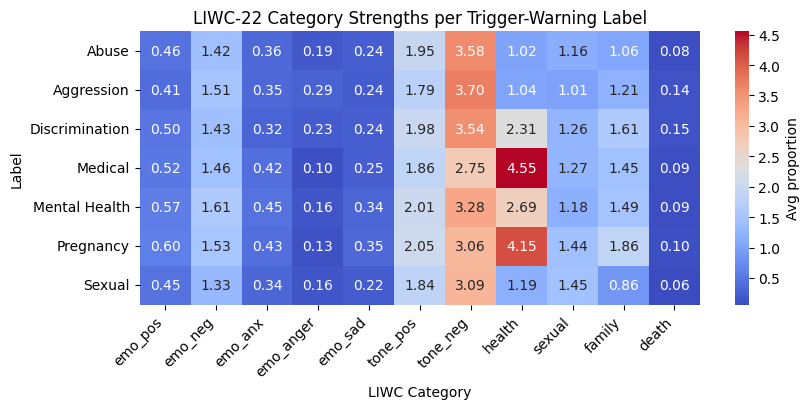

In [5]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# --- adjust if your label column is named differently ---
LABELS_COL = "Tags"

# Ensure multi-label list exists
df[LABELS_COL] = df[LABELS_COL].fillna("").astype(str)
df["labels_list"] = df[LABELS_COL].apply(lambda s: [t.strip() for t in s.split(",") if t.strip()])

# Choose a compact LIWC subset (case-sensitive; adjust names to match your CSV headers)
desired_liwc = [
    "emo_pos","emo_neg","emo_anx","","emo_anger","emo_sad", "tone_pos","tone_neg",
    "health","sexual","family","social","death"
]
use_cols = [c for c in desired_liwc if c in df.columns]
if not use_cols:
    raise ValueError("None of the desired LIWC columns found. Print df.columns and adjust names.")

# Coerce to numeric and report any non-numeric entries that get NaN'ed
non_numeric_report = {}
for c in use_cols:
    before_na = df[c].isna().sum()
    df[c] = pd.to_numeric(df[c], errors="coerce")
    after_na = df[c].isna().sum()
    if after_na > before_na:
        non_numeric_report[c] = int(after_na - before_na)

if non_numeric_report:
    print("ℹ️ Non-numeric values coerced to NaN in these columns:", non_numeric_report)

# Build (label x LIWC) mean table
expl = df.explode("labels_list")
expl = expl[expl["labels_list"].str.lower() != "not applicable"]
heat = expl.groupby("labels_list")[use_cols].mean(numeric_only=True).sort_index()

# Plot
plt.figure(figsize=(min(18, 2 + 0.6*len(use_cols)), 0.6*max(6, len(heat))))
sns.heatmap(heat, cmap="coolwarm", annot=True, fmt=".02f", cbar_kws={"label": "Avg proportion"})
plt.title("LIWC-22 Category Strengths per Trigger-Warning Label")
plt.xlabel("LIWC Category"); plt.ylabel("Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


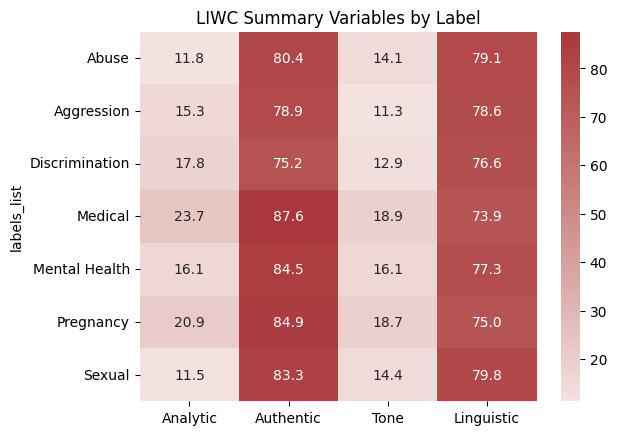

In [6]:
summary_cols = ["Analytic", "Authentic", "Tone", "Linguistic"]
expl = df.explode("labels_list")
expl = expl[expl["labels_list"].str.lower() != "not applicable"]
summ = expl.groupby("labels_list")[summary_cols].mean()
sns.heatmap(summ, cmap="vlag", annot=True, fmt=".1f", center=0)
plt.title("LIWC Summary Variables by Label")
plt.show()

# MFT

In [1]:
import pandas as pd
import re

# ----------------------------
# 1) Load eMFD dictionary
# ----------------------------
url = "https://raw.githubusercontent.com/medianeuroscience/eMFD/master/dictionaries/emfd_amp.csv"
emfd_df = pd.read_csv(url)

# eMFD probability columns per foundation
prob_cols = {
    'Care': 'care_p',
    'Fairness': 'fairness_p',
    'Loyalty': 'loyalty_p',
    'Authority': 'authority_p',
    'Sanctity': 'sanctity_p'
}

# Build token -> {foundation: prob} lookup
emfd_dict = {}
for _, row in emfd_df.iterrows():
    word = row['word']
    emfd_dict[word] = {foundation: row[prob_col] for foundation, prob_col in prob_cols.items()}

print(f"✅ eMFD loaded with {len(emfd_dict)} words")


✅ eMFD loaded with 689 words


In [2]:
# ----------------------------
# 2) Define scoring function
# ----------------------------
def score_emfd(text, emfd_lookup):
    scores = {f: 0.0 for f in prob_cols.keys()}
    tokens = re.findall(r"\b\w+\b", str(text).lower())
    for token in tokens:
        if token in emfd_lookup:
            for f in emfd_lookup[token]:
                scores[f] += emfd_lookup[token][f]
    return pd.Series(scores)


In [3]:
# ----------------------------
# 3) Load dataset and prepare text
# ----------------------------
INPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv"

df = pd.read_csv(INPUT_CSV)
print("✅ Loaded CSV. Columns:", df.columns.tolist())

# Combine title + body for best coverage (keeps original cols intact)
df['text_for_emfd'] = (df.get('title', '').fillna('') + ' ' + df.get('body', '').fillna('')).str.strip()

# Optional: sanity check
print("Sample combined text:\n", df['text_for_emfd'].head(3).tolist())


✅ Loaded CSV. Columns: ['id', 'subreddit', 'title', 'body', 'Tags', 'Unnamed: 5']
Sample combined text:
 ['Complications after abortion? Hi everyone, Ive read that abortions don’t cause infertility. There is a part of me that doesn’t fully believe that. Could be my anxiety speaking.\n\nSince my abortion (August 2024), I’ve been bleeding half way through my cycle and after sex, brown spotting, and recently my periods have been late (last three months) and my uterus, ovaries and cervix are so tender it hurts to walk, bend over or even apply a bit of pressure. It isn’t unbearable pain, it’s manageable but rn it’s at its worst and it’s still out of the normal for me. Anyone know what it possibly could be? I have a gynecologist appointment in about 3 weeks but I’m hurting now and I’m getting very worried.', "Second MA abortion today and I'm absolutely terrified advice? I'm having my second MA abortion today and I'm so scared about the pain. I've been reading how women say its the most painf

In [4]:
# ----------------------------
# 4) Score with eMFD
# ----------------------------
df_emfd_scores = df['text_for_emfd'].apply(score_emfd, emfd_lookup=emfd_dict)

# Optional quick peek
print(df_emfd_scores.head())


       Care  Fairness   Loyalty  Authority  Sanctity
0  0.878207  0.372379  0.371060   0.349925  0.310602
1  3.527730  1.751110  1.384314   1.567656  1.110090
2  0.584083  0.378408  0.474411   0.426658  0.225331
3  0.102941  0.055556  0.064516   0.075758  0.065789
4  1.525603  0.882439  0.968267   0.701727  0.748145


In [6]:
import os

output_dir = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final"
os.makedirs(output_dir, exist_ok=True)

print("✅ Directory ready:", output_dir)


✅ Directory ready: /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final


In [7]:
df_final = pd.concat([df, df_emfd_scores], axis=1)

OUTPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final/5000_posts_with_emfd_scores.csv"
df_final.to_csv(OUTPUT_CSV, index=False)

print("✅ eMFD scoring complete.")
print("📁 Saved to:", OUTPUT_CSV)


✅ eMFD scoring complete.
📁 Saved to: /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final/5000_posts_with_emfd_scores.csv


In [8]:
# Compute word count of the combined text used for scoring
df_final["word_count"] = df_final["text_for_emfd"].apply(lambda x: len(str(x).split()))

print("✅ Word counts added.")
df_final[["text_for_emfd", "word_count"]].head()

✅ Word counts added.


,text_for_emfd,word_count
0,"Complications after abortion? Hi everyone, Ive...",124
1,Second MA abortion today and I'm absolutely te...,204
2,Help needed/ live in Texas where abortion in b...,37
3,medical abortion at 6 weeks I’ll be doing my p...,45
4,Idk what to feel about my decision after doing...,143


In [9]:
# Normalize (divide each moral score by word_count)
for foundation in ["Care", "Fairness", "Loyalty", "Authority", "Sanctity"]:
    df_final[f"{foundation}_norm"] = df_final[foundation] / df_final["word_count"]

print("✅ Normalized columns created:")
print([col for col in df_final.columns if col.endswith("_norm")])


✅ Normalized columns created:
['Care_norm', 'Fairness_norm', 'Loyalty_norm', 'Authority_norm', 'Sanctity_norm']


In [10]:
import os

OUTPUT_DIR = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV = OUTPUT_DIR + "/5000_posts_with_emfd_scores_normalized.csv"
df_final.to_csv(OUTPUT_CSV, index=False)

print("✅ Normalized eMFD scores saved successfully!")
print("📁 File location:", OUTPUT_CSV)


✅ Normalized eMFD scores saved successfully!
📁 File location: /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final/5000_posts_with_emfd_scores_normalized.csv


In [30]:
# Ensure Tags column is treated as text
df_final["Tags"] = df_final["Tags"].astype(str)

# Split comma-separated tags into lists
df_final["Tags_list"] = df_final["Tags"].str.split(",")

# Remove extra spaces around tags
df_final["Tags_list"] = df_final["Tags_list"].apply(lambda lst: [t.strip() for t in lst])

# Expand so each (post, tag) is its own row
df_exploded = df_final.explode("Tags_list")

print("✅ Tags expanded. Unique tags found:")
print(df_exploded["Tags_list"].unique())


✅ Tags expanded. Unique tags found:
['Medical' 'Pregnancy' 'Mental Health' 'Sexual' 'Abuse' 'Discrimination'
 'Aggression' 'Not Applicable' 'nan']


In [12]:
# List of normalized foundation columns
norm_cols = ["Care_norm", "Fairness_norm", "Loyalty_norm", "Authority_norm", "Sanctity_norm"]

tag_means = df_exploded.groupby("Tags_list")[norm_cols].mean().sort_index()

print("✅ Tag-wise moral foundation intensities calculated:")
tag_means


✅ Tag-wise moral foundation intensities calculated:


,Care_norm,Fairness_norm,Loyalty_norm,Authority_norm,Sanctity_norm
Tags_list,,,,,
Abuse,0.007907,0.006185,0.005936,0.005492,0.005622
Aggression,0.007873,0.006169,0.005908,0.005522,0.005556
Discrimination,0.007757,0.006085,0.005812,0.005376,0.005280
Medical,0.006469,0.004700,0.004395,0.004068,0.003762
Mental Health,0.007258,0.005549,0.005363,0.004899,0.004752
Not Applicable,0.007774,0.006400,0.006058,0.005633,0.005491
Pregnancy,0.006743,0.005046,0.004863,0.004425,0.004141
Sexual,0.006827,0.005413,0.005209,0.004876,0.004784
nan,0.005731,0.003427,0.004078,0.003734,0.003928


In [13]:
OUTPUT_STATS = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final/tag_moral_signatures.csv"
tag_means.to_csv(OUTPUT_STATS)

print("📁 Saved tag-wise breakdown to:", OUTPUT_STATS)


📁 Saved tag-wise breakdown to: /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final/tag_moral_signatures.csv


In [15]:
tag_top_foundations = tag_means.idxmax(axis=1).to_frame(name="Top_Moral_Foundation")

tag_summary = pd.concat([tag_means, tag_top_foundations], axis=1)

tag_summary


,Care_norm,Fairness_norm,Loyalty_norm,Authority_norm,Sanctity_norm,Top_Moral_Foundation
Tags_list,,,,,,
Abuse,0.007907,0.006185,0.005936,0.005492,0.005622,Care_norm
Aggression,0.007873,0.006169,0.005908,0.005522,0.005556,Care_norm
Discrimination,0.007757,0.006085,0.005812,0.005376,0.005280,Care_norm
Medical,0.006469,0.004700,0.004395,0.004068,0.003762,Care_norm
Mental Health,0.007258,0.005549,0.005363,0.004899,0.004752,Care_norm
Not Applicable,0.007774,0.006400,0.006058,0.005633,0.005491,Care_norm
Pregnancy,0.006743,0.005046,0.004863,0.004425,0.004141,Care_norm
Sexual,0.006827,0.005413,0.005209,0.004876,0.004784,Care_norm
nan,0.005731,0.003427,0.004078,0.003734,0.003928,Care_norm


In [22]:
for tag in tag_summary.index:
    row = tag_summary.loc[tag]
    top_foundation = row["Top_Moral_Foundation"]
    top_value = row[top_foundation]

    print(f"• **{tag}** posts most strongly express the **{top_foundation}** foundation "
          f"({top_foundation}_norm ≈ {top_value:.5f}).")


• **Abuse** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00791).
• **Aggression** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00787).
• **Discrimination** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00776).
• **Medical** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00647).
• **Mental Health** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00726).
• **Not Applicable** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00777).
• **Pregnancy** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00674).
• **Sexual** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00683).
• **nan** posts most strongly express the **Care_norm** foundation (Care_norm_norm ≈ 0.00573).


In [17]:
import numpy as np

def top_two(series):
    sorted_vals = series.sort_values(ascending=False)
    return pd.Series({
        "Top1": sorted_vals.index[0],
        "Top1_value": sorted_vals.iloc[0],
        "Top2": sorted_vals.index[1],
        "Top2_value": sorted_vals.iloc[1]
    })

tag_top2 = tag_means.apply(top_two, axis=1)
tag_top2


,Top1,Top1_value,Top2,Top2_value
Tags_list,,,,
Abuse,Care_norm,0.007907,Fairness_norm,0.006185
Aggression,Care_norm,0.007873,Fairness_norm,0.006169
Discrimination,Care_norm,0.007757,Fairness_norm,0.006085
Medical,Care_norm,0.006469,Fairness_norm,0.004700
Mental Health,Care_norm,0.007258,Fairness_norm,0.005549
Not Applicable,Care_norm,0.007774,Fairness_norm,0.006400
Pregnancy,Care_norm,0.006743,Fairness_norm,0.005046
Sexual,Care_norm,0.006827,Fairness_norm,0.005413
nan,Care_norm,0.005731,Loyalty_norm,0.004078


In [19]:
top3_table = []

for tag, row in tag_means.iterrows():
    sorted_vals = row.sort_values(ascending=False)
    f1, f2, f3 = sorted_vals.index[:3]
    v1, v2, v3 = sorted_vals.values[:3]
    top3_table.append([tag, 
                       f1.replace('_norm',''), round(v1,5), 
                       f2.replace('_norm',''), round(v2,5),
                       f3.replace('_norm',''), round(v3,5)])

top3_df = pd.DataFrame(top3_table, columns=[
    "Tag", "Top1", "Top1_value", "Top2", "Top2_value", "Top3", "Top3_value"
])
top3_df


,Tag,Top1,Top1_value,Top2,Top2_value,Top3,Top3_value
0,Abuse,Care,0.00791,Fairness,0.00619,Loyalty,0.00594
1,Aggression,Care,0.00787,Fairness,0.00617,Loyalty,0.00591
2,Discrimination,Care,0.00776,Fairness,0.00608,Loyalty,0.00581
3,Medical,Care,0.00647,Fairness,0.00470,Loyalty,0.00440
4,Mental Health,Care,0.00726,Fairness,0.00555,Loyalty,0.00536
5,Not Applicable,Care,0.00777,Fairness,0.00640,Loyalty,0.00606
6,Pregnancy,Care,0.00674,Fairness,0.00505,Loyalty,0.00486
7,Sexual,Care,0.00683,Fairness,0.00541,Loyalty,0.00521
8,nan,Care,0.00573,Loyalty,0.00408,Sanctity,0.00393


In [23]:
for tag, row in tag_means.iterrows():
    sorted_vals = row.sort_values(ascending=False)
    # Get top 3 foundations and values
    f1, f2, f3 = sorted_vals.index[:3]
    v1, v2, v3 = sorted_vals.values[:3]
    
    print(f"• **{tag}** posts most strongly express the **{f1.replace('_norm','')}** foundation (≈ {v1:.5f}), "
          f"followed by **{f2.replace('_norm','')}** (≈ {v2:.5f}) and **{f3.replace('_norm','')}** (≈ {v3:.5f}).")


• **Abuse** posts most strongly express the **Care** foundation (≈ 0.00791), followed by **Fairness** (≈ 0.00619) and **Loyalty** (≈ 0.00594).
• **Aggression** posts most strongly express the **Care** foundation (≈ 0.00787), followed by **Fairness** (≈ 0.00617) and **Loyalty** (≈ 0.00591).
• **Discrimination** posts most strongly express the **Care** foundation (≈ 0.00776), followed by **Fairness** (≈ 0.00608) and **Loyalty** (≈ 0.00581).
• **Medical** posts most strongly express the **Care** foundation (≈ 0.00647), followed by **Fairness** (≈ 0.00470) and **Loyalty** (≈ 0.00440).
• **Mental Health** posts most strongly express the **Care** foundation (≈ 0.00726), followed by **Fairness** (≈ 0.00555) and **Loyalty** (≈ 0.00536).
• **Not Applicable** posts most strongly express the **Care** foundation (≈ 0.00777), followed by **Fairness** (≈ 0.00640) and **Loyalty** (≈ 0.00606).
• **Pregnancy** posts most strongly express the **Care** foundation (≈ 0.00674), followed by **Fairness** (≈ 

In [32]:
df_exploded = df_exploded[df_exploded["Tags_list"].notna()]
df_exploded = df_exploded[df_exploded["Tags_list"].str.lower() != "nan"]


In [33]:
norm_cols = ["Care_norm", "Fairness_norm", "Loyalty_norm", "Authority_norm", "Sanctity_norm"]

tag_means = df_exploded.groupby("Tags_list")[norm_cols].mean().sort_index()


In [34]:
print(tag_means.index.tolist())


['Abuse', 'Aggression', 'Discrimination', 'Medical', 'Mental Health', 'Not Applicable', 'Pregnancy', 'Sexual']


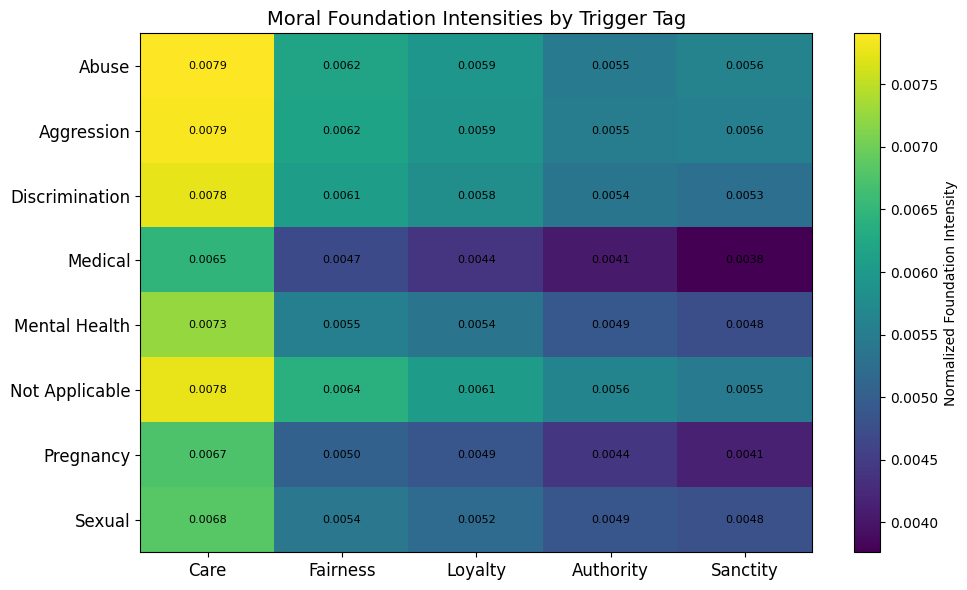

In [35]:
import numpy as np
import matplotlib.pyplot as plt

data = tag_means.values
tags = tag_means.index.astype(str).tolist()
foundations = [c.replace("_norm","") for c in tag_means.columns.tolist()]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(data, aspect="auto")

# Axis labels
ax.set_xticks(np.arange(len(foundations)))
ax.set_xticklabels(foundations, fontsize=12)
ax.set_yticks(np.arange(len(tags)))
ax.set_yticklabels(tags, fontsize=12)

# Annotate values
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]:.4f}", ha="center", va="center", fontsize=8)

ax.set_title("Moral Foundation Intensities by Trigger Tag", fontsize=14)
plt.colorbar(im, label="Normalized Foundation Intensity")
plt.tight_layout()
plt.show()


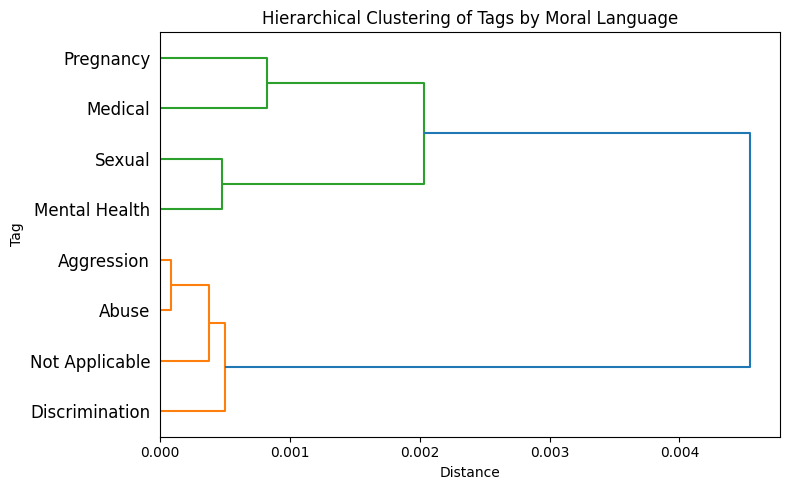

In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(tag_means.values, method="ward")

plt.figure(figsize=(8, 5))
dendrogram(Z, labels=tag_means.index.astype(str).tolist(), orientation="right")
plt.title("Hierarchical Clustering of Tags by Moral Language")
plt.xlabel("Distance")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()


# NEW MFT

In [1]:
import pandas as pd
import spacy

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Input CSV
INPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv"
df = pd.read_csv(INPUT_CSV)

# Combine title + body for full context
df["text_for_emfd"] = (df["title"].fillna('') + " " + df["body"].fillna('')).str.strip()

print("✅ Loaded:", df.shape, "rows")
df.head(2)[["id","title","body","text_for_emfd"]]


✅ Loaded: (4994, 7) rows


,id,title,body,text_for_emfd
0,1ljxynj,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Complications after abortion? Hi everyone, Ive..."
1,1ljxtt8,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,Second MA abortion today and I'm absolutely te...


In [2]:
from spacy.lang.en.stop_words import STOP_WORDS

# Remove stop-words for scoring (keeps semantic words only)
def clean_text_stopwords(text):
    doc = nlp(str(text))
    tokens = [t.text for t in doc if t.text.lower() not in STOP_WORDS]
    return " ".join(tokens)

df["text_for_emfd_clean"] = df["text_for_emfd"].apply(clean_text_stopwords)
print("✅ Stop-word cleaning complete.")

# Load eMFD dictionary (probability weights)
url = "https://raw.githubusercontent.com/medianeuroscience/eMFD/master/dictionaries/emfd_amp.csv"
emfd_df = pd.read_csv(url)

prob_cols = {
    'Care': 'care_p',
    'Fairness': 'fairness_p',
    'Loyalty': 'loyalty_p',
    'Authority': 'authority_p',
    'Sanctity': 'sanctity_p'
}

# Build lookup: word → {foundation: prob}
emfd_dict = {}
for _, row in emfd_df.iterrows():
    word = str(row['word']).lower()
    emfd_dict[word] = {f: float(row[col]) for f, col in prob_cols.items()}

foundations = list(prob_cols.keys())
print("✅ eMFD dictionary size:", len(emfd_dict))
emfd_df.head()

✅ Stop-word cleaning complete.
✅ eMFD dictionary size: 689


,word,care_hlcts,fairness_hlcts,loyalty_hlcts,authority_hlcts,sanctity_hlcts,total_seen,seen_care,seen_fairness,seen_loyalty,...,fairness.virtue,loyalty.virtue,authority.virtue,sanctity.virtue,care.vice,fairness.vice,loyalty.vice,authority.vice,sanctity.vice,foundation
0,liked,0.0,1.0,5.0,2.0,2.0,107.0,17.0,21.0,29.0,...,0.047619,0.172414,0.086957,0.117647,0.0,0.0,0.0,0.0,0.0,loyalty.virtue
1,successor,2.0,2.0,9.0,2.0,2.0,192.0,35.0,43.0,46.0,...,0.046512,0.195652,0.066667,0.052632,0.0,0.0,0.0,0.0,0.0,loyalty.virtue
2,effective,15.0,9.0,4.0,11.0,10.0,487.0,100.0,109.0,80.0,...,0.082569,0.050000,0.095652,0.120482,0.0,0.0,0.0,0.0,0.0,care.virtue
3,agreement,13.0,20.0,27.0,11.0,7.0,930.0,199.0,219.0,224.0,...,0.091324,0.120536,0.079710,0.046667,0.0,0.0,0.0,0.0,0.0,loyalty.virtue
4,fit,2.0,3.0,2.0,4.0,5.0,208.0,59.0,31.0,36.0,...,0.096774,0.055556,0.083333,0.138889,0.0,0.0,0.0,0.0,0.0,sanctity.virtue


In [4]:
# from collections import Counter

# def score_emfd_majority_pos(text, emfd_lookup, foundations):
#     """Compute eMFD scores normalized by the majority POS among moral tokens."""
#     scores = {f: 0.0 for f in foundations}
#     text = str(text) if text is not None else ""
#     if not text.strip():
#         return pd.Series(scores)

#     doc = nlp(text)

#     # Collect moral tokens + their POS
#     moral_pos = []
#     for tok in doc:
#         lemma = tok.lemma_.lower()
#         if lemma in emfd_lookup:
#             moral_pos.append(tok.pos_)
#             for f in foundations:
#                 scores[f] += emfd_lookup[lemma][f]

#     if not moral_pos:
#         return pd.Series(scores)

#     # Majority POS among moral tokens
#     majority_pos = Counter(moral_pos).most_common(1)[0][0]

#     # Denominator = tokens in whole doc with that POS
#     denom = sum(1 for t in doc if t.pos_ == majority_pos)
#     if denom > 0:
#         for f in foundations:
#             scores[f] /= denom

#     return pd.Series(scores)

from collections import Counter

def score_emfd_raw(text, emfd_lookup, foundations):
    """Compute raw (unnormalized) eMFD foundation sums for each post."""
    scores = {f: 0.0 for f in foundations}
    text = str(text) if text else ""
    if not text.strip():
        return pd.Series(scores)

    doc = nlp(text)
    for tok in doc:
        lemma = tok.lemma_.lower()
        if lemma in emfd_lookup:
            for f in foundations:
                scores[f] += emfd_lookup[lemma][f]
    return pd.Series(scores)


# Apply on stop-word-cleaned text
df_emfd_major = df["text_for_emfd_clean"].apply(
    score_emfd_raw,
    emfd_lookup=emfd_dict,
    foundations=foundations
)

# Merge back
df_final_major = pd.concat([df, df_emfd_major], axis=1)

# Quick sanity check
display(df_final_major[foundations].describe(percentiles=[.1,.25,.5,.75,.9]))

,Care,Fairness,Loyalty,Authority,Sanctity
count,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000
mean,2.502814,2.046667,1.974893,1.812065,1.771883
std,2.904011,2.405284,2.314985,2.126956,2.140478
min,0.000000,0.000000,0.000000,0.000000,0.000000
10%,0.336378,0.264599,0.252343,0.231855,0.200698
25%,0.787860,0.627263,0.592229,0.539192,0.522204
50%,1.685939,1.344855,1.283426,1.189536,1.152504
75%,3.154903,2.617069,2.541195,2.312536,2.251684
90%,5.546899,4.540235,4.415544,4.034670,3.994320
max,60.342819,54.413622,49.357173,46.098652,51.796808


In [25]:
from collections import Counter
import pandas as pd

def get_top_pos(text, top_n=2):
    doc = nlp(str(text))
    pos_counts = Counter(tok.pos_ for tok in doc)
    total = sum(pos_counts.values())
    if total == 0:
        return pd.Series({"Top1_POS": None, "Top1_Prop": 0, "Top2_POS": None, "Top2_Prop": 0})
    
    # Get top N POS sorted by frequency
    top_pos = pos_counts.most_common(top_n)
    top_pos += [(None, 0)] * (top_n - len(top_pos))  # pad if fewer POS
    
    return pd.Series({
        "Top1_POS": top_pos[0][0],
        "Top1_Prop": top_pos[0][1] / total,
        "Top2_POS": top_pos[1][0],
        "Top2_Prop": top_pos[1][1] / total
    })

# Apply to a subset (or all if you want)
pos_summary = df_final_major["text_for_emfd_clean"].apply(get_top_pos)

# Merge with tags for inspection
df_pos_analysis = pd.concat([df_final_major[["Tags", "text_for_emfd_clean"]], pos_summary], axis=1)

# Sort by dominance (Top1 proportion)
df_top_pos = df_pos_analysis.sort_values("Top1_Prop", ascending=False)

# Preview top performers
display(df_top_pos.head(20)[["Tags", "Top1_POS", "Top1_Prop", "Top2_POS", "Top2_Prop", "text_for_emfd_clean"]])

,Tags,Top1_POS,Top1_Prop,Top2_POS,Top2_Prop,text_for_emfd_clean
771,Not Applicable,PUNCT,0.750000,VERB,0.250000,. [ removed ]
1487,Not Applicable,PUNCT,0.750000,VERB,0.250000,? [ removed ]
3370,Not Applicable,PROPN,0.666667,SYM,0.166667,ban r / meToo Thank .
3486,Not Applicable,PUNCT,0.666667,ADJ,0.333333,[ removed ]
4481,Not Applicable,PUNCT,0.666667,ADJ,0.333333,[ removed ]
3844,Not Applicable,PUNCT,0.666667,NOUN,0.166667,victim ? ? [ removed ]
3976,Not Applicable,PUNCT,0.666667,ADJ,0.333333,[ removed ]
3334,"Abuse, Sexual, Mental Health",NOUN,0.642857,PUNCT,0.285714,"rest life ? label incest , cause assault inces..."
3488,Not Applicable,NOUN,0.625000,PROPN,0.250000,pee poo pants lol u t troled libtard
2404,Not Applicable,PUNCT,0.600000,NOUN,0.200000,victim ? [ removed ]


In [26]:
OUTPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final/5000_posts_with_eMFD_MajorityPOS.csv"
df_final_major.to_csv(OUTPUT_CSV, index=False)

print("✅ Majority-POS + Stop-word normalized eMFD scoring complete.")
print("📁 Saved to:", OUTPUT_CSV)

✅ Majority-POS + Stop-word normalized eMFD scoring complete.
📁 Saved to: /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_Final/5000_posts_with_eMFD_MajorityPOS.csv


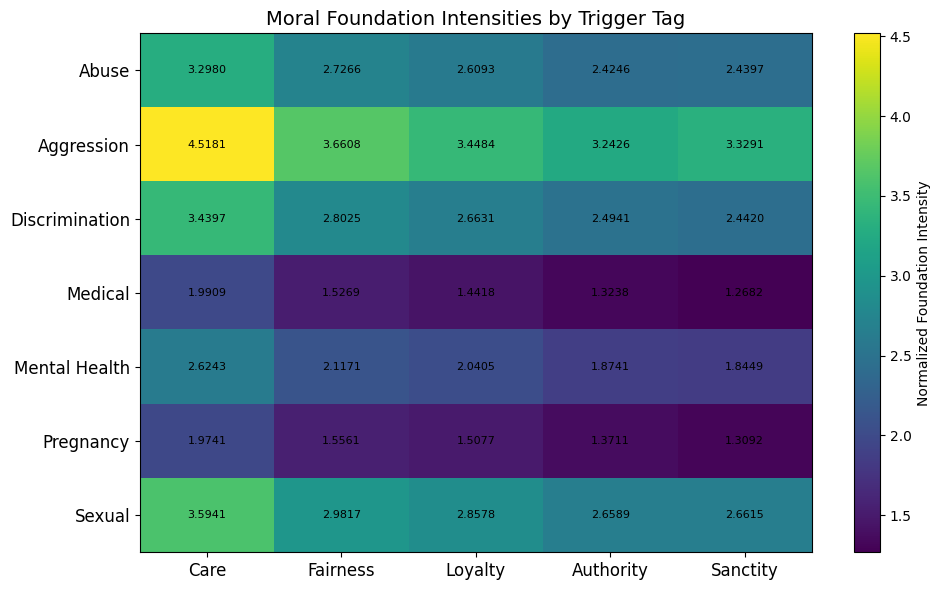

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- 1) Columns and copy ---
FOUNDATION_COLS = ["Care","Fairness","Loyalty","Authority","Sanctity"]

df_tmp = df_final_major.copy()
df_tmp["Tags"] = df_tmp["Tags"].astype(str).str.strip()

# --- 2) Split tags FIRST (handles multi-label rows) ---
# Split on commas, semicolons, or pipes, keep lone tags as-is
df_split = df_tmp.assign(
    Tags=df_tmp["Tags"].apply(lambda x: re.split(r"\s*[,;|]\s*", x) if isinstance(x, str) else [x])
).explode("Tags", ignore_index=True)

# Clean up spacing
df_split["Tags"] = df_split["Tags"].astype(str).str.strip()

# --- 3) Robust filtering AFTER explode ---
_invalid = {
    "", "nan", "none", "null", "n/a", "na",
    "not applicable", "not_applicable", "not-applicable"
}
tags_lower = df_split["Tags"].str.lower().str.strip()
df_valid = df_split.loc[~tags_lower.isin(_invalid)].copy()

# (Optional) Quick sanity check
# print(sorted(df_valid["Tags"].unique()))

# --- 4) Compute mean moral foundation values per tag ---
tag_means = (
    df_valid
    .groupby("Tags")[FOUNDATION_COLS]
    .mean()
    .sort_index()
)

# Optional: rename columns for consistent naming convention with *_norm
tag_means = tag_means.rename(columns={c: f"{c}_norm" for c in FOUNDATION_COLS})

# --- 5) Prepare data for heatmap ---
data = tag_means.values
tags = tag_means.index.astype(str).tolist()
foundations = [c.replace("_norm","") for c in tag_means.columns.tolist()]

# --- 6) Plot the heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(data, aspect="auto")

# Axis labels
ax.set_xticks(np.arange(len(foundations)))
ax.set_xticklabels(foundations, fontsize=12)
ax.set_yticks(np.arange(len(tags)))
ax.set_yticklabels(tags, fontsize=12)

# Annotate values
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]:.4f}", ha="center", va="center", fontsize=8)

ax.set_title("Moral Foundation Intensities by Trigger Tag", fontsize=14)
plt.colorbar(im, label="Normalized Foundation Intensity")
plt.tight_layout()
plt.show()

In [10]:
import re

# Split multi-label entries into individual tags
df_split = df_final_major.assign(
    Tags=df_final_major["Tags"].apply(lambda x: re.split(r"\s*[,;|]\s*", str(x)) if isinstance(x, str) else [x])
).explode("Tags", ignore_index=True)

# Clean and filter invalid entries
_invalid = {"", "nan", "none", "null", "n/a", "na", "not applicable"}
df_split["Tags"] = df_split["Tags"].astype(str).str.strip()
df_valid = df_split.loc[~df_split["Tags"].str.lower().isin(_invalid)].copy()

# Now group properly
tag_means_raw = (
    df_valid.groupby("Tags")[["Care","Fairness","Loyalty","Authority","Sanctity"]]
    .mean()
    .sort_index()
)

display(tag_means_raw)

,Care,Fairness,Loyalty,Authority,Sanctity
Tags,,,,,
Abuse,3.298049,2.726624,2.609298,2.424617,2.439660
Aggression,4.518086,3.660800,3.448402,3.242601,3.329134
Discrimination,3.439678,2.802530,2.663116,2.494105,2.442010
Medical,1.990894,1.526933,1.441834,1.323754,1.268233
Mental Health,2.624255,2.117079,2.040467,1.874101,1.844919
Pregnancy,1.974139,1.556071,1.507748,1.371148,1.309171
Sexual,3.594145,2.981682,2.857824,2.658927,2.661467


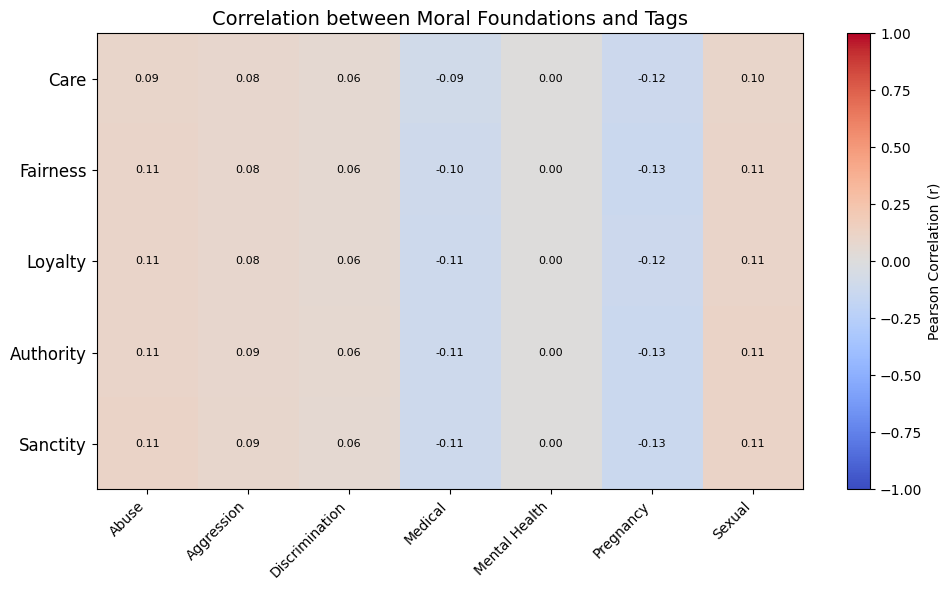

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- 1) Define moral foundation columns ---
FOUNDATION_COLS = ["Care", "Fairness", "Loyalty", "Authority", "Sanctity"]

# --- 2) Clean & split tags (multi-label safe) ---
df_tmp = df_final_major.copy()
df_tmp["Tags"] = df_tmp["Tags"].astype(str).str.strip()

# Split multi-tag strings by comma/semicolon/pipe, then explode into rows
df_split = df_tmp.assign(
    Tags=df_tmp["Tags"].apply(
        lambda x: re.split(r"\s*[,;|]\s*", x) if isinstance(x, str) else [x]
    )
).explode("Tags", ignore_index=True)

# Clean up spaces and remove invalid entries
_invalid = {
    "", "nan", "none", "null", "n/a", "na",
    "not applicable", "not_applicable", "not-applicable"
}
df_split["Tags"] = df_split["Tags"].astype(str).str.strip()
tags_lower = df_split["Tags"].str.lower()
df_valid = df_split.loc[~tags_lower.isin(_invalid)].copy()

# --- 3) One-hot encode tags ---
dummies = pd.get_dummies(df_valid["Tags"], prefix="tag")

# --- 4) Combine moral foundation scores + one-hot tag columns ---
corr_df = pd.concat([df_valid[FOUNDATION_COLS], dummies], axis=1)

# --- 5) Compute Pearson correlation matrix ---
corr_matrix = corr_df.corr().loc[FOUNDATION_COLS, dummies.columns]

# --- 6) Plot correlation heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(corr_matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(np.arange(len(dummies.columns)))
ax.set_xticklabels([c.replace("tag_", "") for c in dummies.columns],
                   rotation=45, ha="right", fontsize=10)
ax.set_yticks(np.arange(len(FOUNDATION_COLS)))
ax.set_yticklabels(FOUNDATION_COLS, fontsize=12)

# Annotate correlation values
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color="black")

ax.set_title("Correlation between Moral Foundations and Tags", fontsize=14)
plt.colorbar(im, label="Pearson Correlation (r)")
plt.tight_layout()
plt.show()